# Distribution Analysis

> Understanding the structure of the Diabetes 130-US dataset before running federated experiments.
> This notebook has two goals:
> 1. **Global distributions** — class-conditional feature statistics that inform what the FedGen generator *should* learn to approximate.
> 2. **Dirichlet heterogeneity** — how client distributions diverge from the global as α decreases, providing an empirical basis for the accuracy-vs-communication-cost Pareto analysis.

---

# First chapter: Clinical Analysis

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, entropy, ks_2samp
import warnings
import sys
import os
import json

warnings.filterwarnings('ignore')
sys.path.append('..')

from UC1Utils import (
    load_data, drop_columns, remove_deceased, create_target,
    encode_features, _impute_and_group_specialty,
    prepare_data, ensure_data, CSV_MAIN, derive_global_columns
)
from UC1FLUtils import dirichlet_partition, find_feasible_params, preprocess_clients, verify_leakage, load_clients, create_clients_raw_csv, load_partitions_from_disk

plt.rcParams.update({
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = {'Not readmitted (0)': '#4878CF', 'Readmitted <30d (1)': '#E24A33'}
ALPHA_SWEEP = [0.1, 0.5, 1.0, 5.0,10.0]
N_CLIENTS   = 5
SEED        = 42
FEDERATED_DIR  = '../federated_data'
FILTERED_DIR   = os.path.join(FEDERATED_DIR, 'filtered')
UNFILTERED_DIR = os.path.join(FEDERATED_DIR, 'unfiltered')

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

We work at two levels:
- **Raw DataFrame** (pre-OHE) — for clinical feature distributions.
- **Encoded matrix** (post-OHE) — for federated partitioning and Wasserstein analysis.

In [19]:
ensure_data()

# ── Load and preprocess up to (but not including) OHE ─────────────────────────
# We keep a pre-OHE DataFrame for clinical interpretation.
df_raw = load_data(CSV_MAIN)
df_raw = drop_columns(df_raw)
df_raw = remove_deceased(df_raw)
df_raw = create_target(df_raw)
df_raw['race'] = df_raw['race'].fillna('Unknown')
df_raw = _impute_and_group_specialty(df_raw)
df_raw['A1Cresult']     = df_raw['A1Cresult'].fillna('none')
df_raw['max_glu_serum'] = df_raw['max_glu_serum'].fillna('none')
df_raw.dropna(inplace=True)

# Apply encode_features which adds engineered columns but also OHEs —
# we'll rebuild a pre-OHE version for visualization.
# The approach: apply everything EXCEPT get_dummies by reconstructing manually.
from UC1Utils import AGE_MAP, ADMISSION_TYPE_MAP, ADMISSION_SOURCE_MAP, MED_MAP, MED_COLS, LOW_INFO_MEDS
from UC1Utils import group_discharge, group_icd9

df = df_raw.copy()
df['age'] = df['age'].map(AGE_MAP)
df['service_utilization'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']
df['admission_type_id']        = df['admission_type_id'].map(ADMISSION_TYPE_MAP).fillna('unknown')
df['admission_source_id']      = df['admission_source_id'].map(ADMISSION_SOURCE_MAP).fillna('unknown')
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(group_discharge)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(group_icd9)
for col in MED_COLS:
    if col in df.columns:
        df[col] = df[col].map(MED_MAP)
active_meds = [c for c in MED_COLS if c in df.columns]
df['medication_count'] = df[active_meds].sum(axis=1)
df.drop(columns=[c for c in LOW_INFO_MEDS if c in df.columns], inplace=True)
df['HbA1c_diabetes_interaction'] = (
    (df['A1Cresult'] != 'none') & (df['diag_1'] == 'diabetes')
).astype(int)
df['change']      = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# ── Fully encoded matrix ───────────────────────────────────────────────────────
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)

df_enc = pd.DataFrame(X, columns=feature_names)
df_enc['readmitted_binary'] = y

print(f'\nPre-OHE DataFrame: {df.shape}')
print(f'Encoded matrix:    {df_enc.shape}')

✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)

Pre-OHE DataFrame: (97825, 40)
Encoded matrix:    (97825, 100)


## 2. Global Class Distribution

The 7.73:1 imbalance is the single most structurally important property of this dataset.
It directly affects what the generator must learn: class 1 is rare, so its latent
representations are also sparsely sampled during generator training.

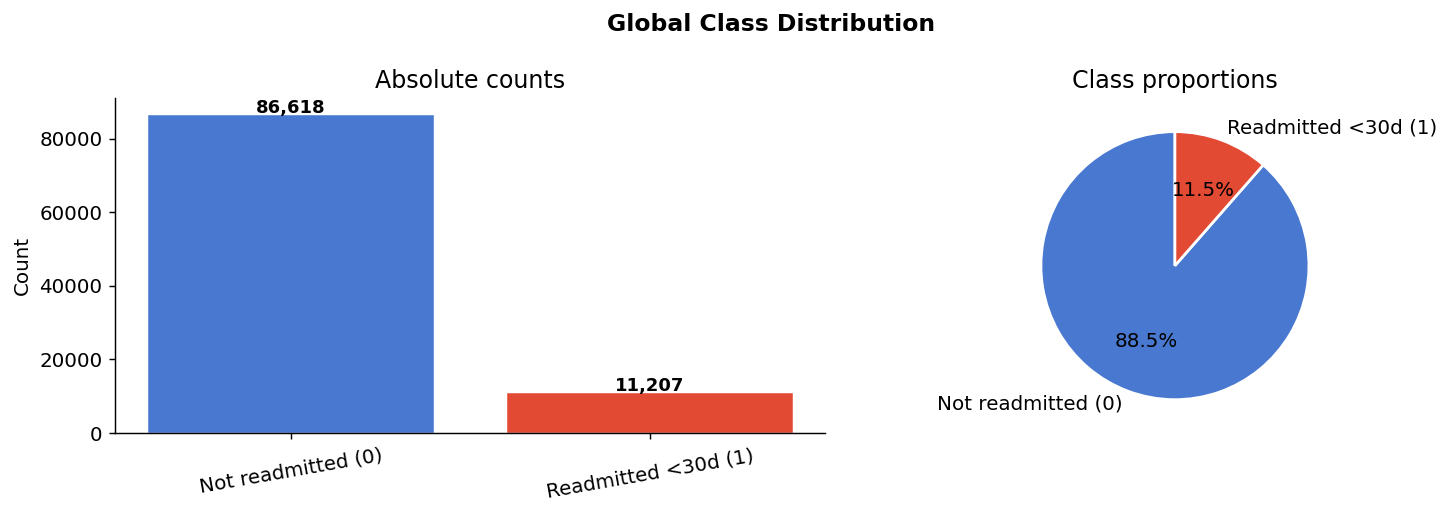

Imbalance ratio: 7.73:1  |  Positive rate: 11.46%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Global Class Distribution', fontweight='bold', fontsize=13)

counts = pd.Series(y).value_counts().sort_index()
labels = ['Not readmitted (0)', 'Readmitted <30d (1)']
colors = list(PALETTE.values())

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Absolute counts')
axes[0].tick_params(axis='x', rotation=10)

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: {counts[0]/counts[1]:.2f}:1  |  Positive rate: {counts[1]/len(y)*100:.2f}%')

## 3. Class-Conditional Distributions: Continuous Features

These are the features whose class-conditional distributions the generator is implicitly
trying to capture in latent space. Large separations between the two class distributions
indicate high discriminative power — and also indicate where a biased local dataset
will produce the worst model drift.

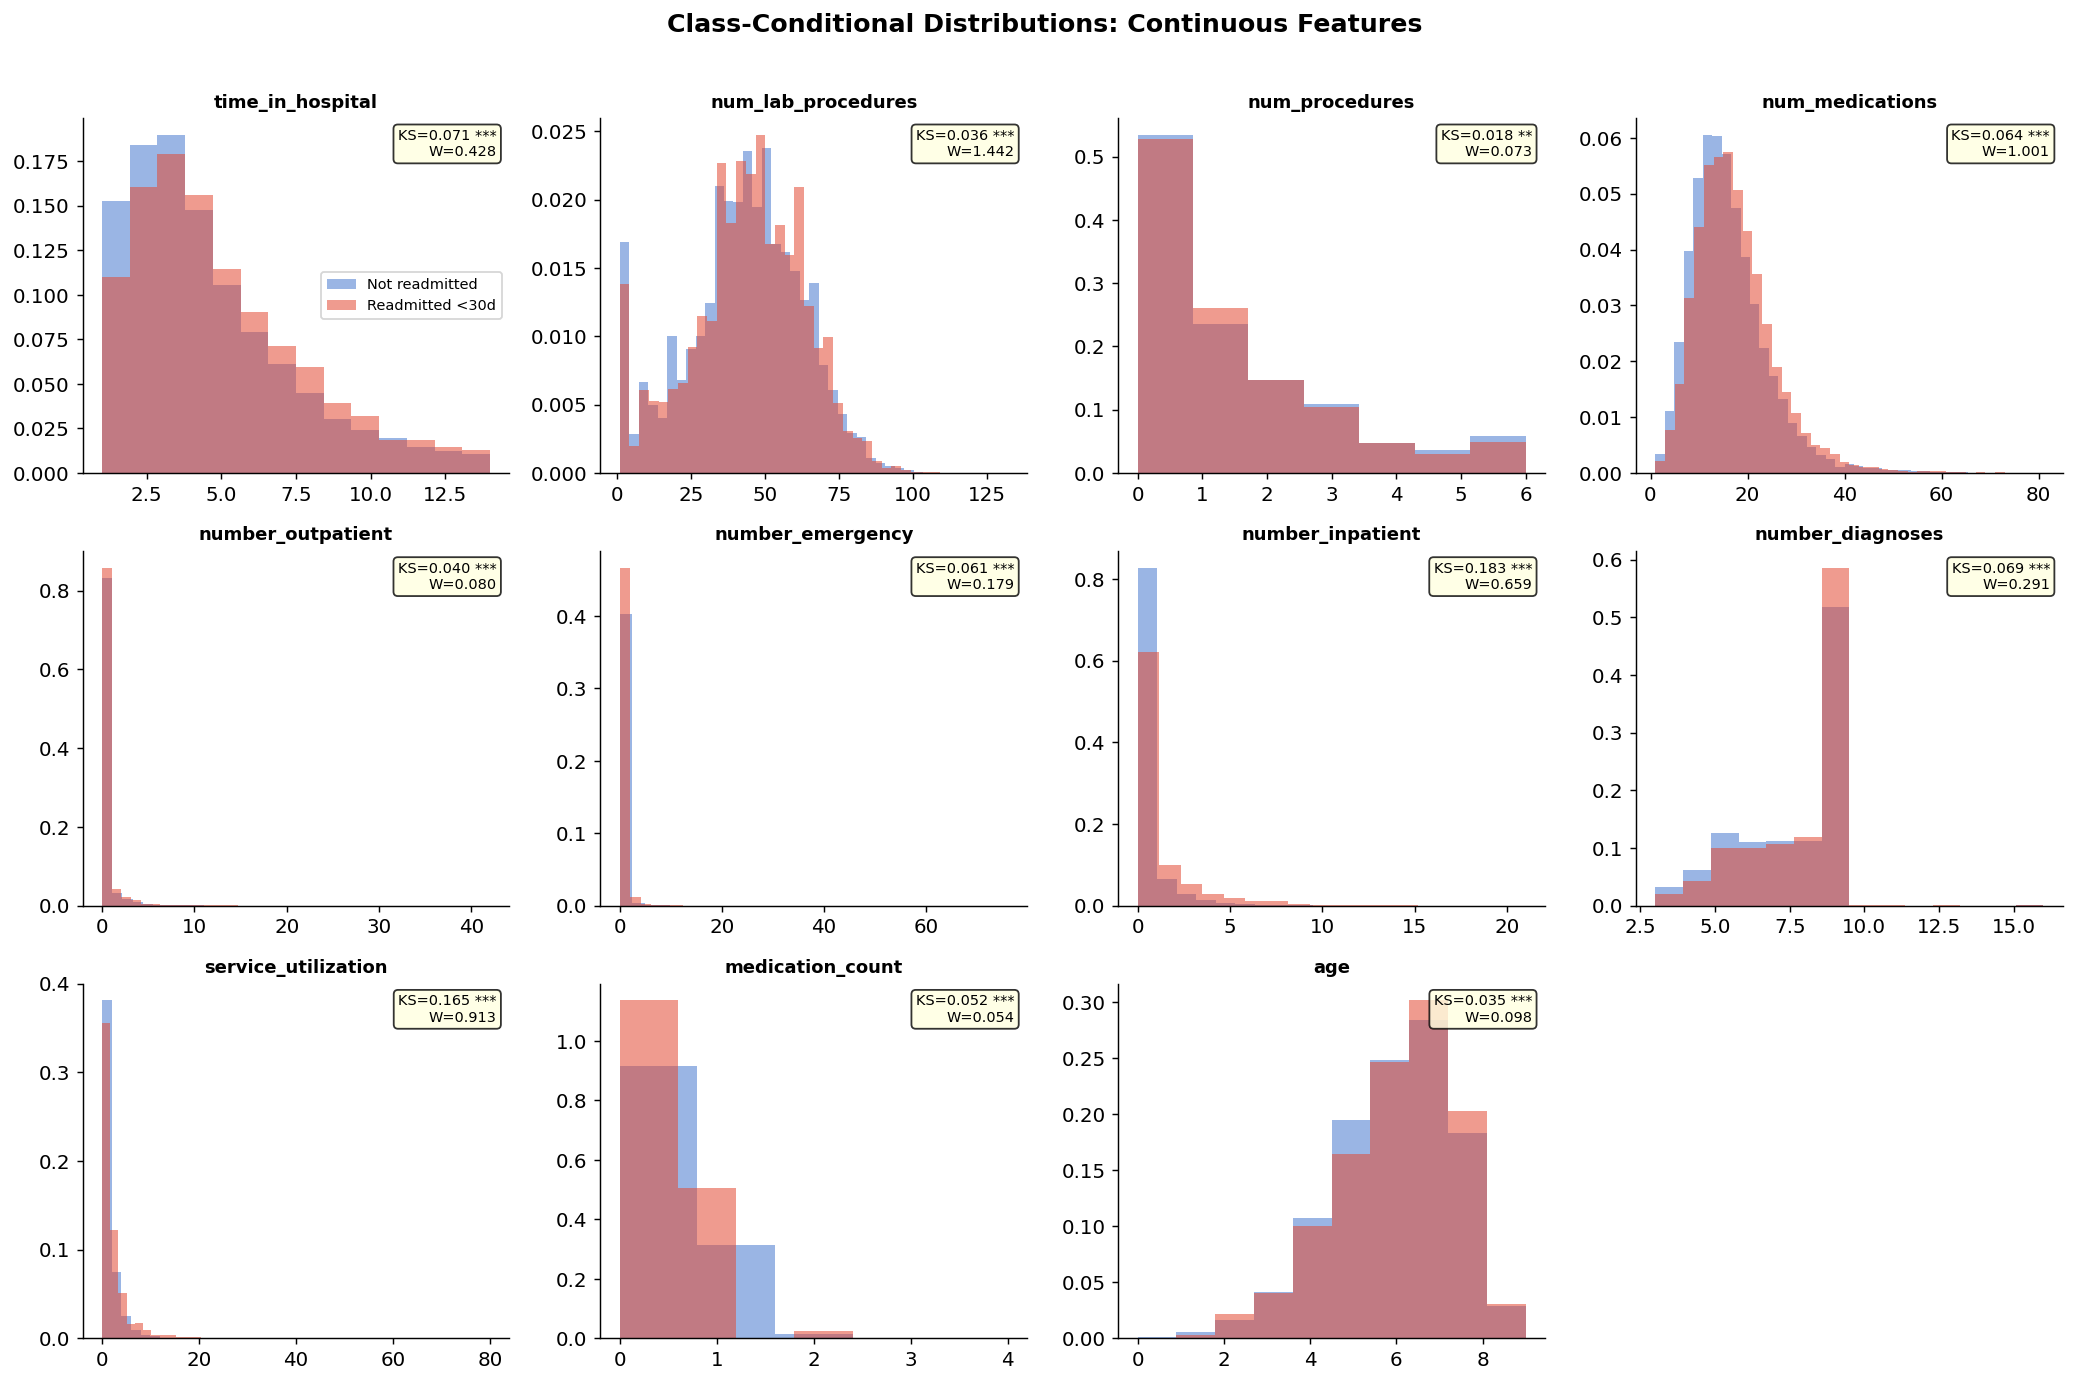


Kolmogorov-Smirnov test: class-conditional separation
(Higher KS = more discriminative, more sensitive to distribution shift)

            Feature  KS statistic       p-value Significant
   number_inpatient      0.183136 9.717136e-292         ***
service_utilization      0.164981 1.659051e-236         ***
   time_in_hospital      0.071369  2.139068e-44         ***
   number_diagnoses      0.068886  2.184919e-41         ***
    num_medications      0.064051  7.788025e-36         ***
   number_emergency      0.061086  1.245366e-32         ***
   medication_count      0.052175  6.441043e-24         ***
  number_outpatient      0.040167  2.393455e-14         ***
 num_lab_procedures      0.035678  2.073279e-11         ***
                age      0.034581  9.583534e-11         ***
     num_procedures      0.017578  4.290620e-03            


In [21]:
CONTINUOUS_FEATURES = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'service_utilization', 'medication_count', 'age'
]

n_cols = 4
n_rows = int(np.ceil(len(CONTINUOUS_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Class-Conditional Distributions: Continuous Features', fontweight='bold', fontsize=14, y=1.01)
axes = axes.flatten()

df0 = df[df['readmitted_binary'] == 0]
df1 = df[df['readmitted_binary'] == 1]

ks_results = {}

for i, feat in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    v0 = df0[feat].dropna()
    v1 = df1[feat].dropna()

    ks_stat, ks_p = ks_2samp(v0, v1)
    ks_results[feat] = (ks_stat, ks_p)
    wass = wasserstein_distance(v0, v1)

    # KDE plots
    bins = min(40, int(v0.nunique()))
    ax.hist(v0, bins=bins, alpha=0.55, color=list(PALETTE.values())[0],
            density=True, label='Not readmitted')
    ax.hist(v1, bins=bins, alpha=0.55, color=list(PALETTE.values())[1],
            density=True, label='Readmitted <30d')

    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    sign = '***' if ks_p < 0.001 else ('**' if ks_p < 0.01 else ('*' if ks_p < 0.05 else 'ns'))
    ax.annotate(f'KS={ks_stat:.3f} {sign}\nW={wass:.3f}',
                xy=(0.97, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_class_conditional_continuous.png', bbox_inches='tight')
plt.show()

# Summary table sorted by KS statistic (discriminative power)
ks_df = pd.DataFrame([
    {'Feature': k, 'KS statistic': v[0], 'p-value': v[1],
     'Significant': '***' if v[1] < 0.001 else ''}
    for k, v in ks_results.items()
]).sort_values('KS statistic', ascending=False).reset_index(drop=True)

print('\nKolmogorov-Smirnov test: class-conditional separation')
print('(Higher KS = more discriminative, more sensitive to distribution shift)\n')
print(ks_df.to_string(index=False))

## 4. Class-Conditional Distributions: Key Categorical Features

Categorical features after grouping. The proportions per class matter for the generator
because the label prior $\hat{p}(y)$ is used to sample labels during generator training.

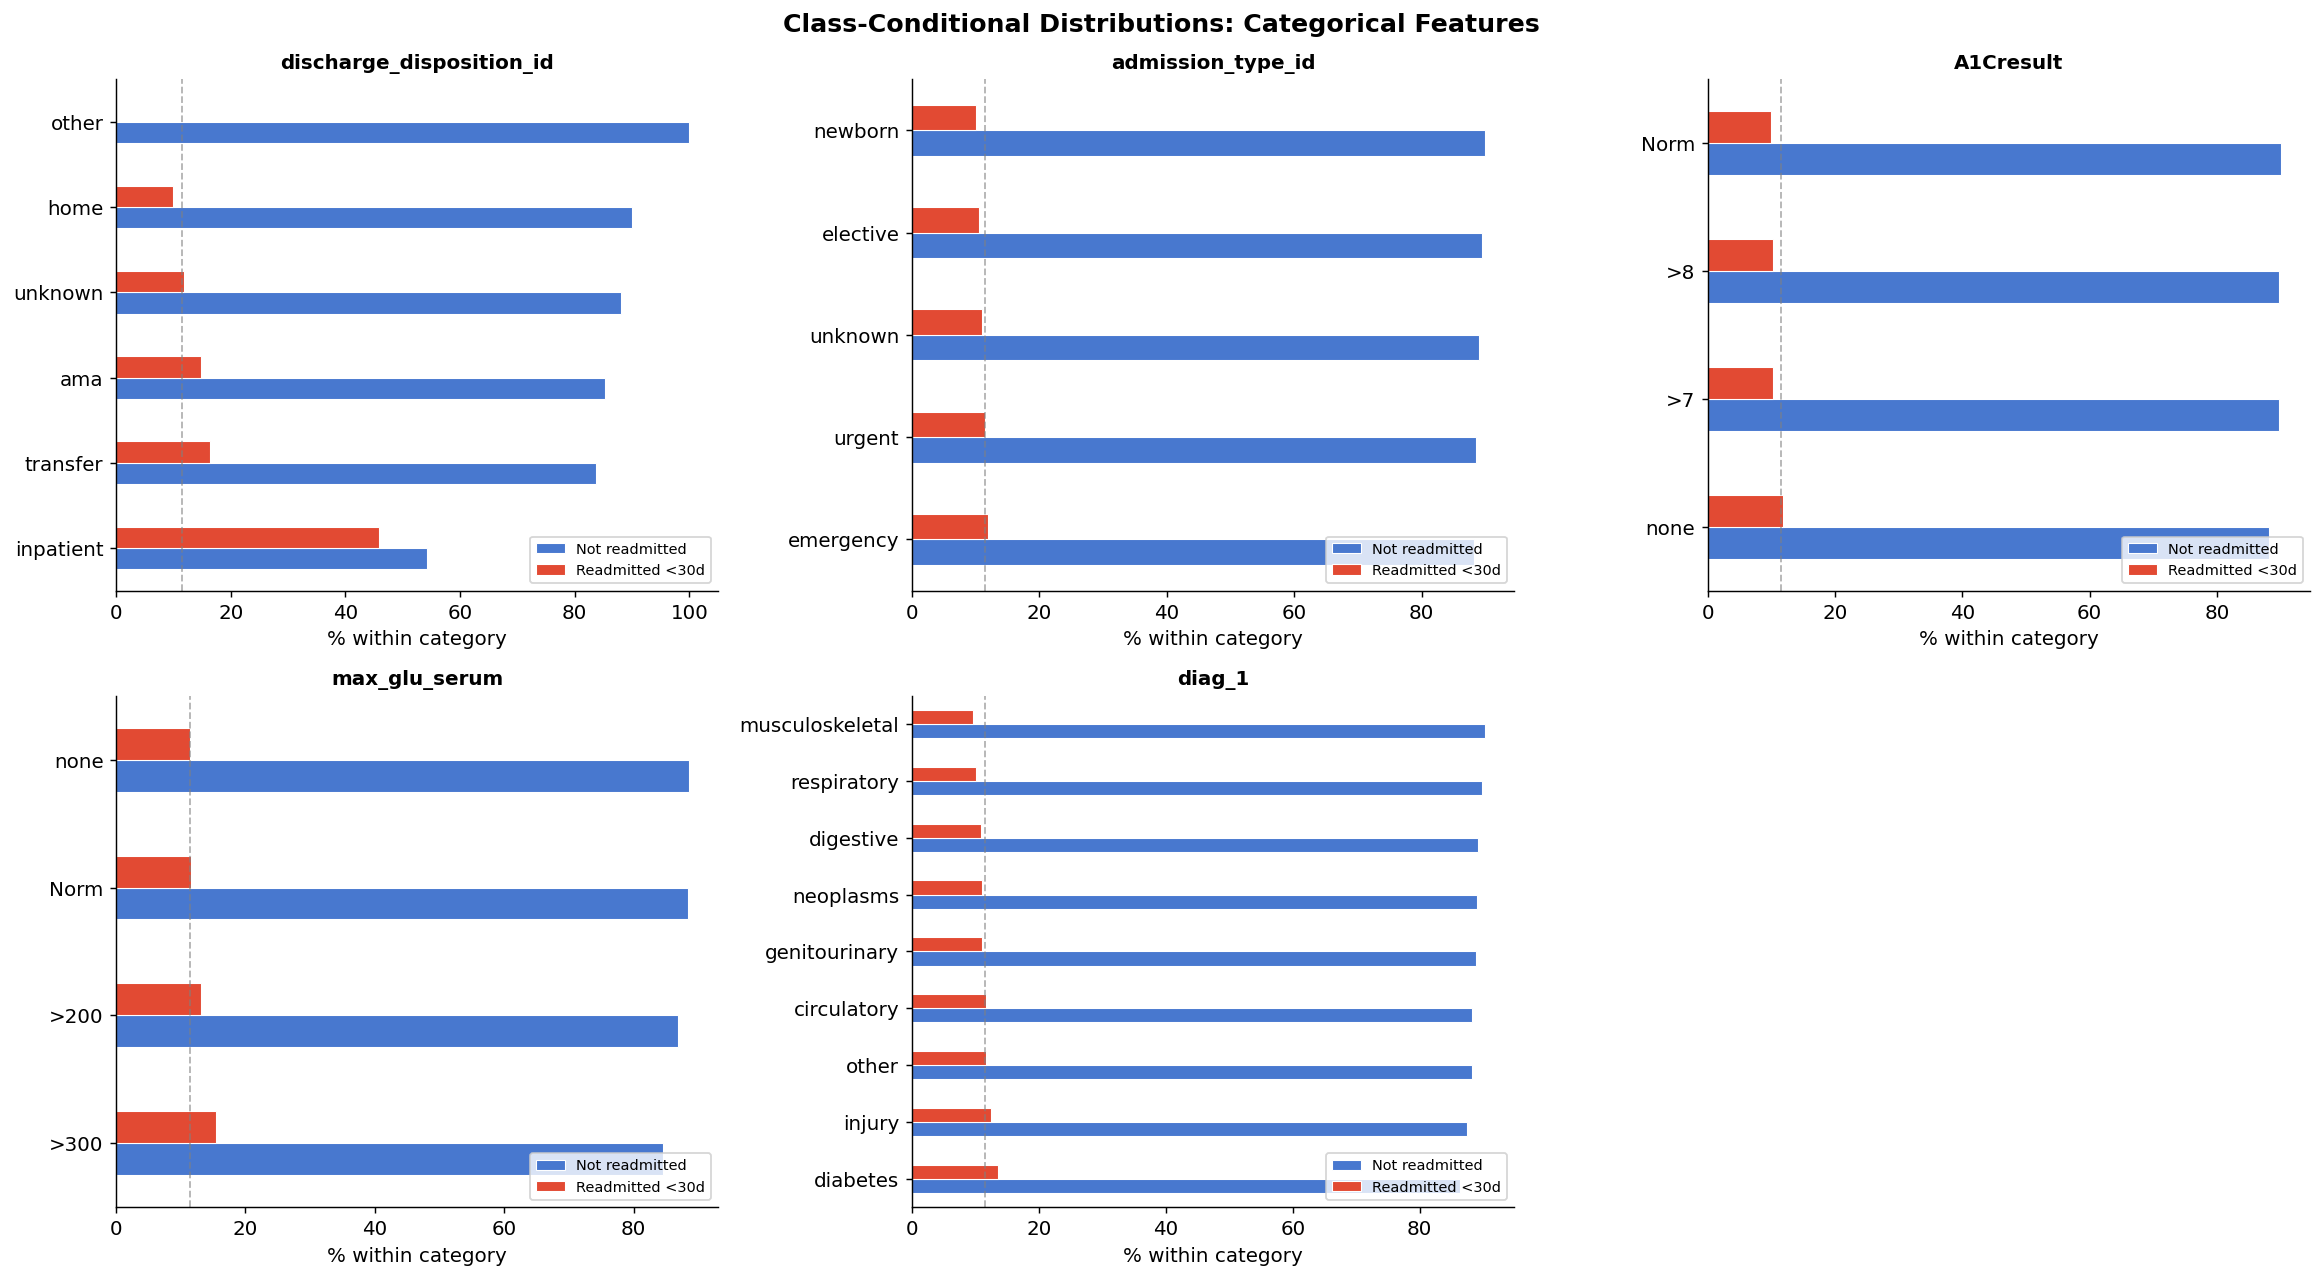

In [22]:
CAT_FEATURES = [
    'discharge_disposition_id', 'admission_type_id',
    'A1Cresult', 'max_glu_serum', 'diag_1'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Class-Conditional Distributions: Categorical Features', fontweight='bold', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(CAT_FEATURES):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df['readmitted_binary'], normalize='index') * 100
    ct.columns = ['Not readmitted', 'Readmitted <30d']
    ct.sort_values('Readmitted <30d', ascending=False, inplace=True)

    ct.plot(kind='barh', ax=ax, color=list(PALETTE.values()),
            edgecolor='white', linewidth=0.6)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('% within category')
    ax.set_ylabel('')
    ax.legend(fontsize=8, loc='lower right')
    ax.axvline(x=y.mean() * 100, color='gray', linestyle='--', alpha=0.6, linewidth=1)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('figures/03_class_conditional_categorical.png', bbox_inches='tight')
plt.show()

## 5. Engineered Features: Clinical Validation

These three features — `service_utilization`, `medication_count`, and
`HbA1c_diabetes_interaction` — were added based on the literature.
This section validates that they actually carry the expected signal.

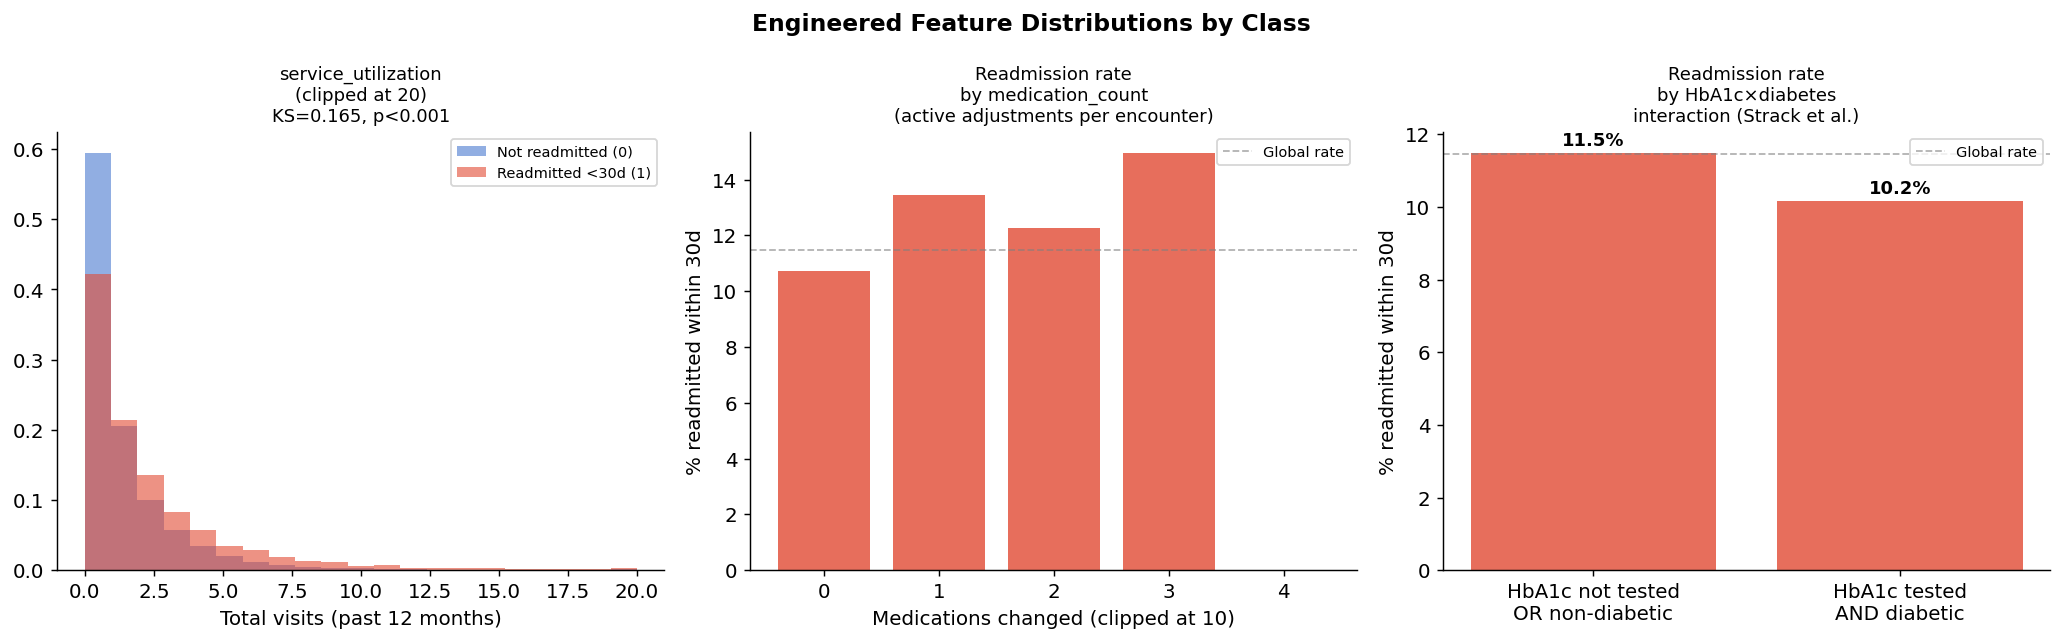

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Engineered Feature Distributions by Class', fontweight='bold', fontsize=13)

# ── service_utilization ───────────────────────────────────────────────────────
ax = axes[0]
for label, color in zip([0, 1], list(PALETTE.values())):
    vals = df[df['readmitted_binary'] == label]['service_utilization']
    ax.hist(vals.clip(upper=20), bins=21, alpha=0.6, color=color,
            density=True, label=list(PALETTE.keys())[label])
ks_s, ks_p = ks_2samp(
    df[df['readmitted_binary']==0]['service_utilization'],
    df[df['readmitted_binary']==1]['service_utilization']
)
ax.set_title(f'service_utilization\n(clipped at 20)\nKS={ks_s:.3f}, p<0.001', fontsize=10)
ax.set_xlabel('Total visits (past 12 months)')
ax.legend(fontsize=8)

# ── medication_count ──────────────────────────────────────────────────────────
ax = axes[1]
mc_cross = pd.crosstab(
    df['medication_count'].clip(upper=10),
    df['readmitted_binary'],
    normalize='index'
) * 100
if 1 in mc_cross.columns:
    ax.bar(mc_cross.index, mc_cross[1], color=list(PALETTE.values())[1], alpha=0.8)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
ax.set_title('Readmission rate\nby medication_count\n(active adjustments per encounter)', fontsize=10)
ax.set_xlabel('Medications changed (clipped at 10)')
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

# ── HbA1c_diabetes_interaction ────────────────────────────────────────────────
ax = axes[2]
hba1c_cross = pd.crosstab(
    df['HbA1c_diabetes_interaction'],
    df['readmitted_binary'],
    normalize='index'
) * 100
bar_labels = ['HbA1c not tested\nOR non-diabetic', 'HbA1c tested\nAND diabetic']
bars = ax.bar(
    bar_labels,
    hba1c_cross[1].values if 1 in hba1c_cross.columns else [0, 0],
    color=list(PALETTE.values())[1], alpha=0.8
)
ax.axhline(y.mean()*100, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='Global rate')
for bar, val in zip(bars, hba1c_cross[1].values if 1 in hba1c_cross.columns else []):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Readmission rate\nby HbA1c×diabetes\ninteraction (Strack et al.)', fontsize=10)
ax.set_ylabel('% readmitted within 30d')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/04_engineered_features.png', bbox_inches='tight')
plt.show()

## 6. Feature Correlation and Redundancy

Before studying heterogeneity, it is useful to know which continuous features move together.
Highly correlated features imply that client distribution shift in one will manifest in
correlated shifts in others — the effective dimensionality of the heterogeneity is lower
than the raw feature count.

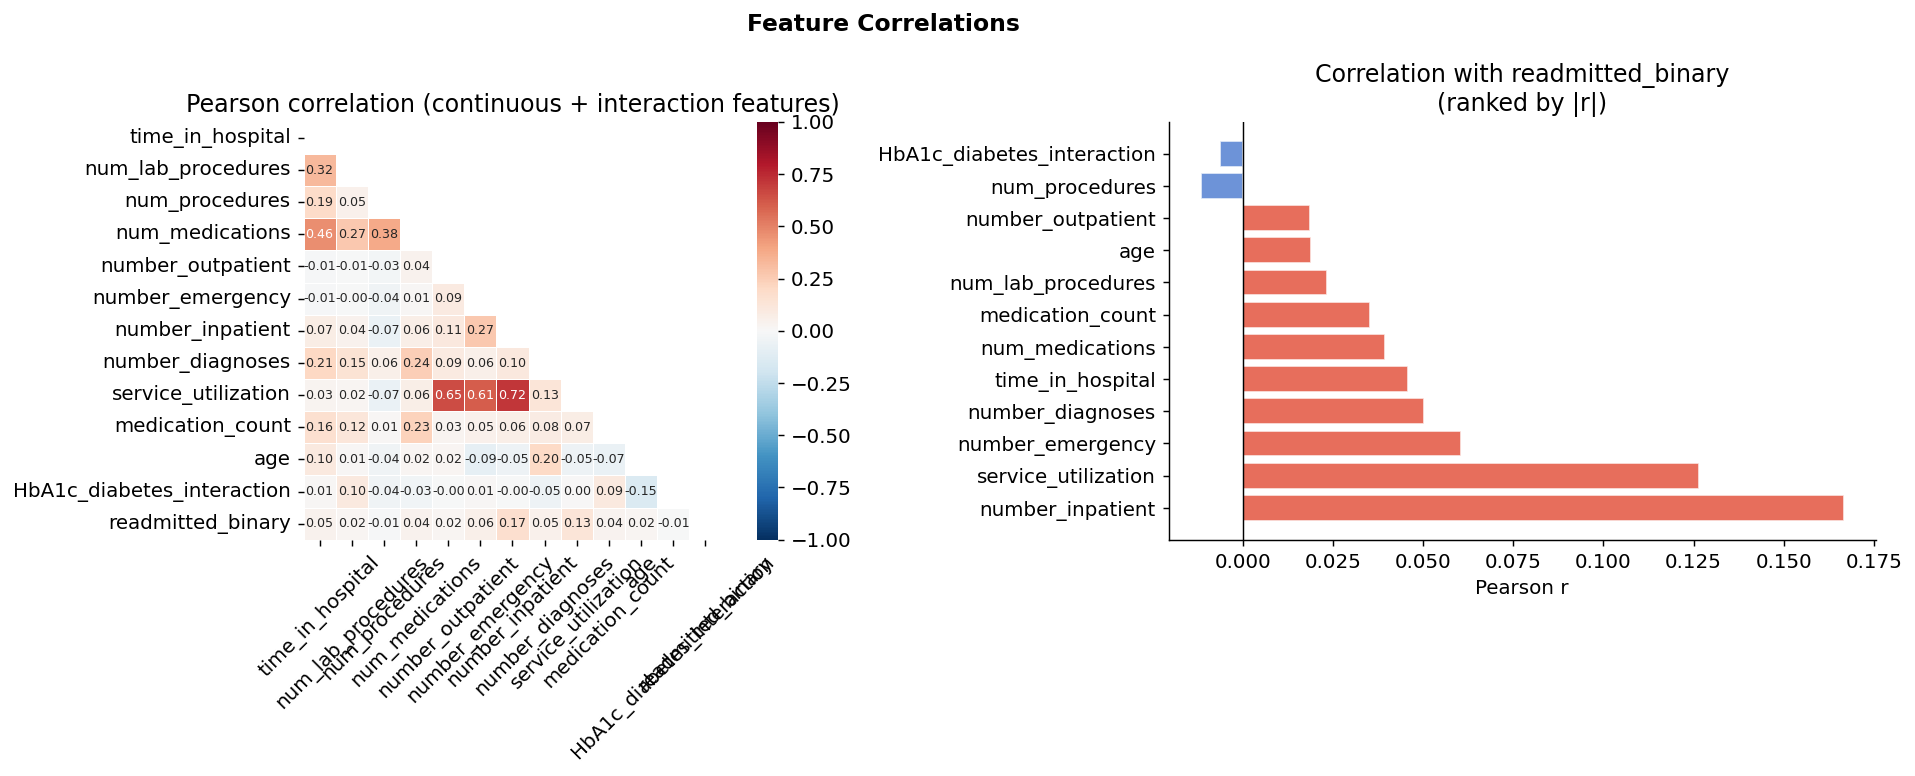

In [24]:
cont_cols = CONTINUOUS_FEATURES + ['HbA1c_diabetes_interaction']
corr = df[cont_cols + ['readmitted_binary']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlations', fontweight='bold', fontsize=13)

# Full correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, square=True
)
axes[0].set_title('Pearson correlation (continuous + interaction features)')
axes[0].tick_params(axis='x', rotation=45)

# Point-biserial correlation with target (discriminative power ranking)
target_corr = corr['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
colors_bar = [list(PALETTE.values())[1] if v > 0 else list(PALETTE.values())[0]
              for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with readmitted_binary\n(ranked by |r|)')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('figures/05_feature_correlations.png', bbox_inches='tight')
plt.show()

## 7. Dirichlet Partitioning: How Heterogeneity Distorts Client Distributions

This is the core of the experimental design. For each α value we generate one
partitioning of patients into 5 clients and visualize:
- The positive rate per client (how skewed the label distributions are).
- The Wasserstein distance of each client's key feature distributions from the global.

The Wasserstein distance $W_1$ is the natural measure of distribution divergence here
because it corresponds directly to the $d_{\mathcal{H}\Delta\mathcal{H}}$ term in
Theorem 1 of the FedGen paper — larger $W_1$ predicts worse global model performance.

In [25]:
# Build patient → label map from the full dataset
df_full_raw = pd.read_csv(CSV_MAIN)
patient_labels_map = (
    df_full_raw.groupby('patient_nbr')['readmitted']
    .apply(lambda x: 1 if (x == '<30').any() else 0)
    .to_dict()
)
unique_patients = np.array(list(patient_labels_map.keys()))

print(f'Unique patients: {len(unique_patients):,}')
print(f'Positive patients (ever readmitted <30d): {sum(patient_labels_map.values()):,}')

Unique patients: 71,518
Positive patients (ever readmitted <30d): 8,834


In [26]:
# ── Federation Setup: paths and global feature schema ─────────────────────────
# Schema is derived once from the full dataset and saved to disk.
# All client preprocessing aligns to this schema so every client produces
# identical feature dimensions regardless of which rare categories appear locally.

os.makedirs(FEDERATED_DIR, exist_ok=True)

global_columns = derive_global_columns(CSV_MAIN)

schema_path = os.path.join(FEDERATED_DIR, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(global_columns, f, indent=2)

print(f'Global schema: {len(global_columns)} columns saved → {schema_path}')

Deriving global feature schema from full dataset...
  99 feature columns
Global schema: 99 columns saved → ../federated_data/feature_schema.json


In [27]:
find_feasible_params(df_full_raw, n_clients_list=[5], alpha_list=[0.5, 1.0, 5.0, 10.0])

Total patients: 71,518 | Positive: 8,834 (12.4%)

 N_clients |    Alpha |  Feasible trials |   Mean min pos_abs |  p5 min pos_abs
---------------------------------------------------------------------------
         5 |    0.500 |              24% |              435.6 |           212.9
         5 |    1.000 |              62% |              533.8 |           223.4
         5 |    5.000 |             100% |              955.0 |           508.6
         5 |   10.000 |             100% |             1162.4 |           758.6


In [43]:
new_data = False
PARTITION_SEED = 42

# ── Filtered ──────────────────────────────────────────────────────────────────
if new_data:
    filtered_partitions = create_clients_raw_csv(
        df_full_raw, FILTERED_DIR, ALPHA_SWEEP,
        filtered=True, seed=PARTITION_SEED
    )
    preprocess_clients(
        FILTERED_DIR, ALPHA_SWEEP, global_columns,
        seed=PARTITION_SEED, regenerate=True
    )
else:
    filtered_partitions = load_partitions_from_disk(
        FILTERED_DIR, ALPHA_SWEEP, patient_labels_map
    )
verify_leakage(ALPHA_SWEEP, output_dir=FILTERED_DIR)

# ── Unfiltered ────────────────────────────────────────────────────────────────
if new_data:
    unfiltered_partitions = create_clients_raw_csv(
        df_full_raw, UNFILTERED_DIR, ALPHA_SWEEP,
        filtered=False, seed=PARTITION_SEED
    )
    preprocess_clients(
        UNFILTERED_DIR, ALPHA_SWEEP, global_columns,
        seed=PARTITION_SEED, regenerate=True
    )
else:
    unfiltered_partitions = load_partitions_from_disk(
        UNFILTERED_DIR, ALPHA_SWEEP, patient_labels_map
    )
verify_leakage(ALPHA_SWEEP, output_dir=UNFILTERED_DIR)

  α=0.1 → 5 clients | sizes: ['33,383', '1,429', '26,817', '3,914', '5,975'] | pos rates: ['0.067', '0.903', '0.049', '0.883', '0.087']
  α=0.5 → 5 clients | sizes: ['3,675', '24,488', '21,343', '2,151', '19,861'] | pos rates: ['0.235', '0.073', '0.227', '0.105', '0.056']
  α=1.0 → 5 clients | sizes: ['22,334', '33,325', '3,889', '5,001', '6,969'] | pos rates: ['0.135', '0.034', '0.200', '0.293', '0.349']
  α=5.0 → 5 clients | sizes: ['21,833', '13,524', '6,993', '13,316', '15,852'] | pos rates: ['0.076', '0.140', '0.070', '0.306', '0.045']
  α=10.0 → 5 clients | sizes: ['19,544', '13,943', '8,922', '13,646', '15,463'] | pos rates: ['0.090', '0.138', '0.088', '0.247', '0.065']

Loaded partitions for α ∈ [0.1, 0.5, 1.0, 5.0, 10.0]
  α=0.1: ✓ zero leakage confirmed
  α=0.5: ✓ zero leakage confirmed
  α=1.0: ✓ zero leakage confirmed
  α=5.0: ✓ zero leakage confirmed
  α=10.0: ✓ zero leakage confirmed
  α=0.1 → 5 clients | sizes: ['3', '20', '62,657', '8,146', '692'] | pos rates: ['0.000',

In [29]:
# ── Visualize positive rate distributions across alpha values ─────────────────
n_alphas = len(filtered_partitions)


In [30]:
n_alphas_unfiltered = len(filtered_partitions)

## 8. Wasserstein Distance: Client vs. Global Distribution

For each (α, client, feature) triplet, we compute the 1-Wasserstein distance between
the client's feature distribution and the global distribution. This quantifies how
much the Dirichlet split distorts each feature's distribution, and for which features
the distortion is strongest.

This directly operationalizes the $d_{\mathcal{H}\Delta\mathcal{H}}$ term from
FedGen's Theorem 1: clients with high Wasserstein distances on discriminative features
are the ones that will benefit most from the generator's inductive bias.

In [31]:
WASS_FEATURES = [
    'time_in_hospital', 'number_inpatient', 'number_emergency',
    'service_utilization', 'medication_count', 'num_medications', 'age'
]

global_distributions = {feat: df[feat].values for feat in WASS_FEATURES}

wass_records = []

for alpha, partition in filtered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        client_df = df[df['patient_nbr'].isin(pid_set)] if 'patient_nbr' in df.columns else df.iloc[:0]
        
        for feat in WASS_FEATURES:
            if feat in df.columns:
                client_vals = df.loc[df['patient_nbr'].isin(pid_set), feat].values if 'patient_nbr' in df.columns else np.array([])
                if len(client_vals) > 10:
                    w = wasserstein_distance(global_distributions[feat], client_vals)
                    wass_records.append({
                        'alpha': alpha, 'client': f'C{client_id}',
                        'feature': feat, 'wasserstein': w
                    })

wass_df = pd.DataFrame(wass_records)
print(wass_df.groupby(['alpha', 'feature'])['wasserstein'].mean().unstack('feature').round(4))

feature     age  medication_count  num_medications  number_emergency  \
alpha                                                                  
0.1      0.0378            0.0227           0.2968            0.0808   
0.5      0.0228            0.0115           0.2060            0.0413   
1.0      0.0302            0.0184           0.1988            0.0578   
5.0      0.0230            0.0125           0.1719            0.0393   
10.0     0.0231            0.0105           0.1434            0.0302   

feature  number_inpatient  service_utilization  time_in_hospital  
alpha                                                             
0.1                0.4049               0.5497            0.1788  
0.5                0.1447               0.2018            0.0865  
1.0                0.2298               0.3167            0.0908  
5.0                0.1407               0.1989            0.0785  
10.0               0.1032               0.1452            0.0589  


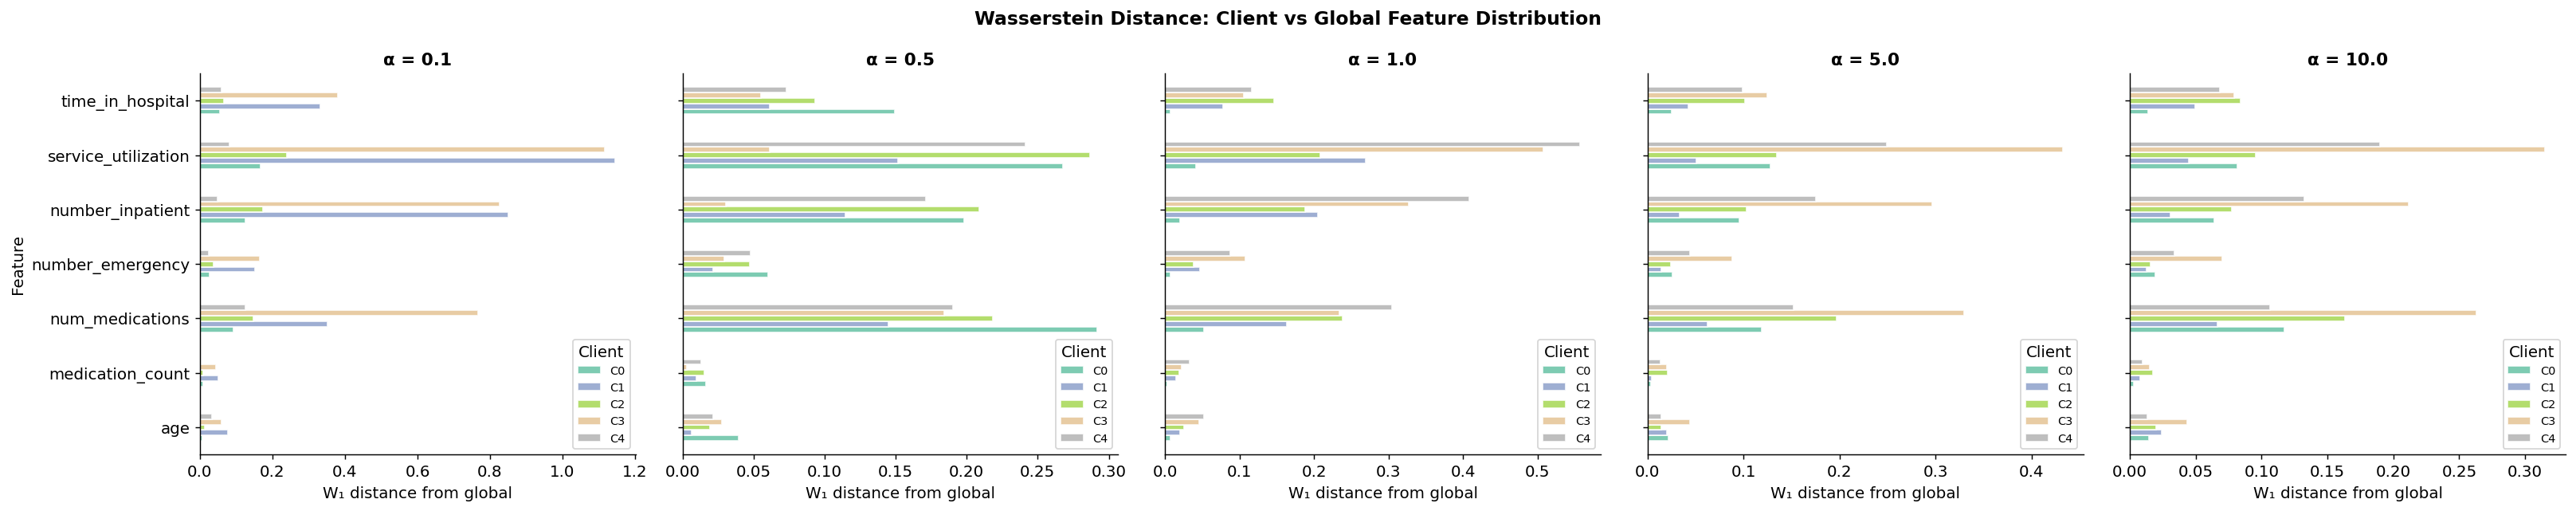

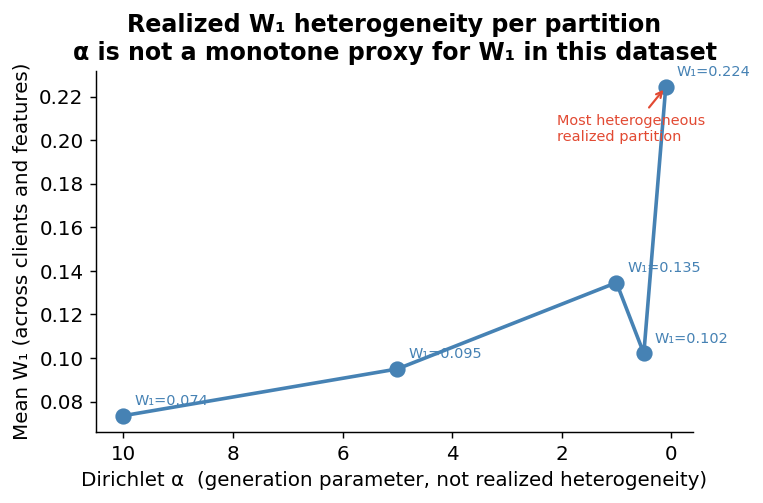

Realized heterogeneity ordering by W₁:
alpha
0.1     0.224487
1.0     0.134639
0.5     0.102092
5.0     0.094980
10.0    0.073516

Note: α ordering ([10.0, 5.0, 1.0, 0.5, 0.1]) does not match W₁ ordering ([0.1, 1.0, 0.5, 5.0, 10.0])
Use W₁ values to anchor the Pareto analysis x-axis, not α alone.


In [32]:
if not wass_df.empty:
    fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 5), sharey=True)
    if len(ALPHA_SWEEP) == 1:
        axes = [axes]
    fig.suptitle('Wasserstein Distance: Client vs Global Feature Distribution',
                 fontweight='bold', fontsize=13)

    for ax, alpha in zip(axes, ALPHA_SWEEP):
        sub = wass_df[wass_df['alpha'] == alpha]
        if sub.empty:
            ax.set_visible(False); continue
        pivot = sub.pivot(index='feature', columns='client', values='wasserstein')
        pivot.plot(kind='barh', ax=ax, colormap='Set2', alpha=0.85, edgecolor='white')
        ax.set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
        ax.set_xlabel('W₁ distance from global')
        ax.set_ylabel('Feature' if ax == axes[0] else '')
        ax.legend(title='Client', fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig('figures/07_wasserstein_distances.png', bbox_inches='tight')
    plt.show()

    # ── Mean W1 per alpha ──────────────────────────────────────────────────────
    # NOTE: W₁ is NOT monotone in α for this dataset.
    # α is a Dirichlet draw parameter — any single realization may not respect
    # the expected heterogeneity ordering. W₁ measures the actual realized
    # divergence and is the reliable metric for the Pareto analysis.
    mean_wass = wass_df.groupby('alpha')['wasserstein'].mean()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(mean_wass.index, mean_wass.values, 'o-', color='steelblue',
            linewidth=2, markersize=8)

    # Annotate each point with its realized W₁ value
    for alpha_val, w1_val in mean_wass.items():
        ax.annotate(f'W₁={w1_val:.3f}',
                    xy=(alpha_val, w1_val),
                    xytext=(6, 6), textcoords='offset points',
                    fontsize=8, color='steelblue')

    ax.set_xlabel('Dirichlet α  (generation parameter, not realized heterogeneity)')
    ax.set_ylabel('Mean W₁ (across clients and features)')
    ax.set_title('Realized W₁ heterogeneity per partition\n'
                 'α is not a monotone proxy for W₁ in this dataset',
                 fontweight='bold')
    ax.invert_xaxis()

    # Identify and annotate the actual most heterogeneous partition
    most_het_alpha = mean_wass.idxmax()
    ax.annotate(f'Most heterogeneous\nrealized partition',
                xy=(most_het_alpha, mean_wass[most_het_alpha]),
                xytext=(-60, -30), textcoords='offset points',
                fontsize=8, color='#E24A33',
                arrowprops=dict(arrowstyle='->', color='#E24A33', lw=1.2))

    plt.tight_layout()
    plt.savefig('figures/08_mean_wasserstein_vs_alpha.png', bbox_inches='tight')
    plt.show()

    print('Realized heterogeneity ordering by W₁:')
    print(mean_wass.sort_values(ascending=False).to_string())
    print(f'\nNote: α ordering ({sorted(mean_wass.index, reverse=True)}) does not match '
          f'W₁ ordering ({list(mean_wass.sort_values(ascending=False).index)})')
    print('Use W₁ values to anchor the Pareto analysis x-axis, not α alone.')

In [33]:
WASS_FEATURES = [
    'time_in_hospital', 'number_inpatient', 'number_emergency',
    'service_utilization', 'medication_count', 'num_medications', 'age'
]

global_distributions = {feat: df[feat].values for feat in WASS_FEATURES}

wass_records = []

for alpha, partition in unfiltered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        client_df = df[df['patient_nbr'].isin(pid_set)] if 'patient_nbr' in df.columns else df.iloc[:0]
        
        for feat in WASS_FEATURES:
            if feat in df.columns:
                client_vals = df.loc[df['patient_nbr'].isin(pid_set), feat].values if 'patient_nbr' in df.columns else np.array([])
                if len(client_vals) > 10:
                    w = wasserstein_distance(global_distributions[feat], client_vals)
                    wass_records.append({
                        'alpha': alpha, 'client': f'C{client_id}',
                        'feature': feat, 'wasserstein': w
                    })

wass_df = pd.DataFrame(wass_records)
print(wass_df.groupby(['alpha', 'feature'])['wasserstein'].mean().unstack('feature').round(4))

feature     age  medication_count  num_medications  number_emergency  \
alpha                                                                  
0.1      0.1249            0.0701           0.9180            0.1948   
0.5      0.0315            0.0227           0.3962            0.0878   
1.0      0.0311            0.0180           0.3063            0.0640   
5.0      0.0230            0.0125           0.1719            0.0393   
10.0     0.0231            0.0105           0.1434            0.0302   

feature  number_inpatient  service_utilization  time_in_hospital  
alpha                                                             
0.1                0.6667               0.9434            0.4194  
0.5                0.4141               0.5581            0.1763  
1.0                0.2770               0.3777            0.1183  
5.0                0.1407               0.1989            0.0785  
10.0               0.1032               0.1452            0.0589  


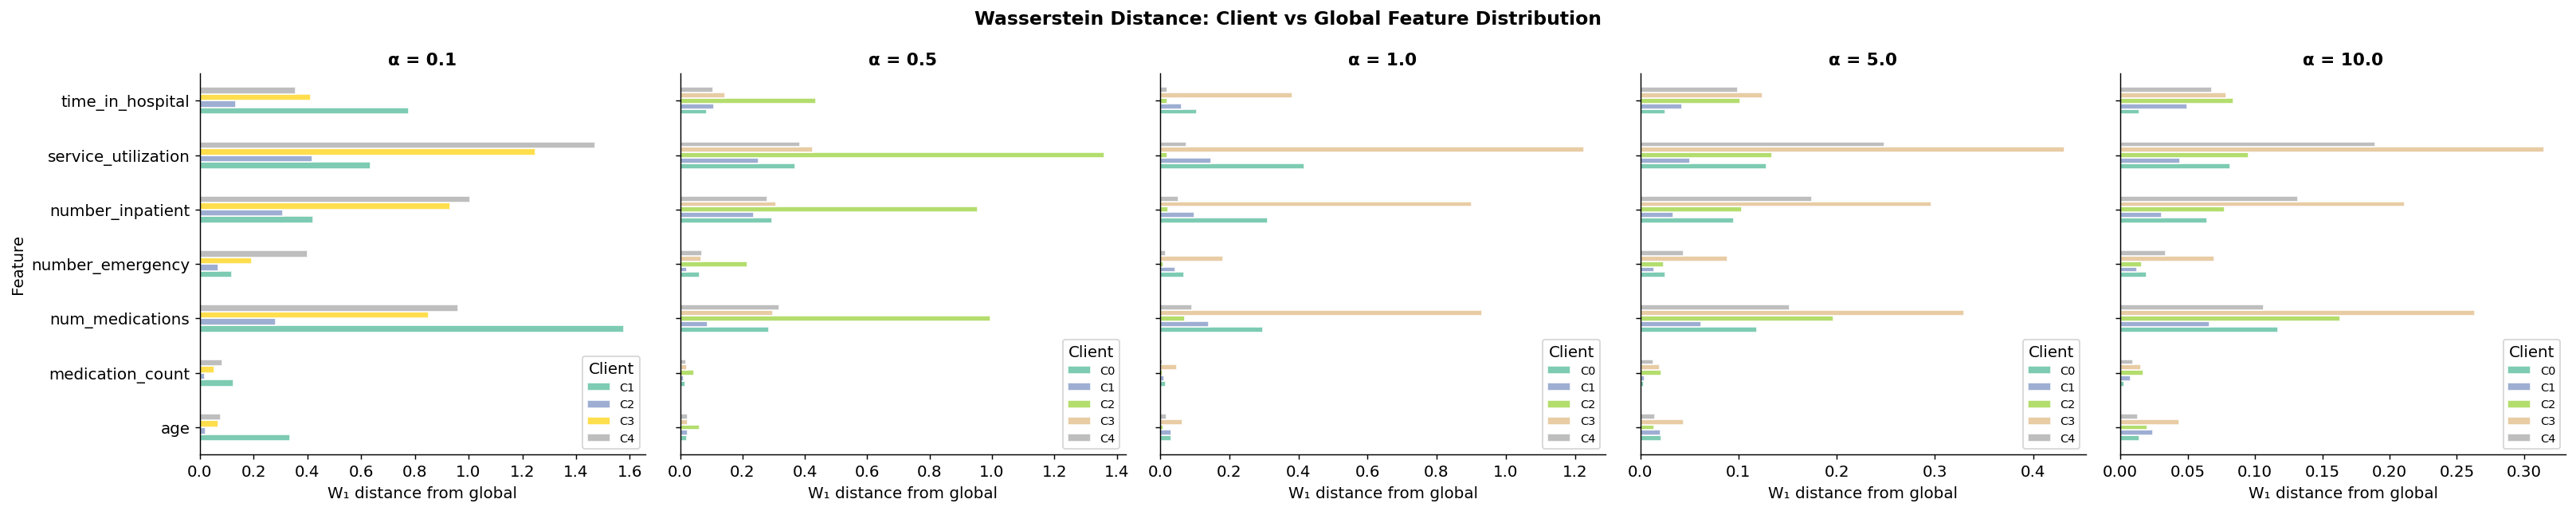

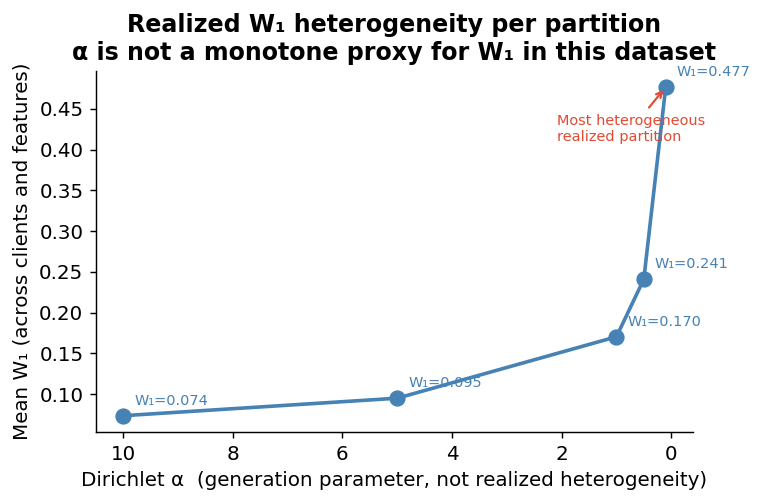

Realized heterogeneity ordering by W₁:
alpha
0.1     0.476755
0.5     0.240957
1.0     0.170345
5.0     0.094980
10.0    0.073516

Note: α ordering ([10.0, 5.0, 1.0, 0.5, 0.1]) does not match W₁ ordering ([0.1, 0.5, 1.0, 5.0, 10.0])
Use W₁ values to anchor the Pareto analysis x-axis, not α alone.


In [34]:
if not wass_df.empty:
    fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 5), sharey=True)
    if len(ALPHA_SWEEP) == 1:
        axes = [axes]
    fig.suptitle('Wasserstein Distance: Client vs Global Feature Distribution',
                 fontweight='bold', fontsize=13)

    for ax, alpha in zip(axes, ALPHA_SWEEP):
        sub = wass_df[wass_df['alpha'] == alpha]
        if sub.empty:
            ax.set_visible(False); continue
        pivot = sub.pivot(index='feature', columns='client', values='wasserstein')
        pivot.plot(kind='barh', ax=ax, colormap='Set2', alpha=0.85, edgecolor='white')
        ax.set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
        ax.set_xlabel('W₁ distance from global')
        ax.set_ylabel('Feature' if ax == axes[0] else '')
        ax.legend(title='Client', fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig('figures/07_wasserstein_distances.png', bbox_inches='tight')
    plt.show()

    # ── Mean W1 per alpha ──────────────────────────────────────────────────────
    # NOTE: W₁ is NOT monotone in α for this dataset.
    # α is a Dirichlet draw parameter — any single realization may not respect
    # the expected heterogeneity ordering. W₁ measures the actual realized
    # divergence and is the reliable metric for the Pareto analysis.
    mean_wass = wass_df.groupby('alpha')['wasserstein'].mean()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(mean_wass.index, mean_wass.values, 'o-', color='steelblue',
            linewidth=2, markersize=8)

    # Annotate each point with its realized W₁ value
    for alpha_val, w1_val in mean_wass.items():
        ax.annotate(f'W₁={w1_val:.3f}',
                    xy=(alpha_val, w1_val),
                    xytext=(6, 6), textcoords='offset points',
                    fontsize=8, color='steelblue')

    ax.set_xlabel('Dirichlet α  (generation parameter, not realized heterogeneity)')
    ax.set_ylabel('Mean W₁ (across clients and features)')
    ax.set_title('Realized W₁ heterogeneity per partition\n'
                 'α is not a monotone proxy for W₁ in this dataset',
                 fontweight='bold')
    ax.invert_xaxis()

    # Identify and annotate the actual most heterogeneous partition
    most_het_alpha = mean_wass.idxmax()
    ax.annotate(f'Most heterogeneous\nrealized partition',
                xy=(most_het_alpha, mean_wass[most_het_alpha]),
                xytext=(-60, -30), textcoords='offset points',
                fontsize=8, color='#E24A33',
                arrowprops=dict(arrowstyle='->', color='#E24A33', lw=1.2))

    plt.tight_layout()
    plt.savefig('figures/08_mean_wasserstein_vs_alpha.png', bbox_inches='tight')
    plt.show()

    print('Realized heterogeneity ordering by W₁:')
    print(mean_wass.sort_values(ascending=False).to_string())
    print(f'\nNote: α ordering ({sorted(mean_wass.index, reverse=True)}) does not match '
          f'W₁ ordering ({list(mean_wass.sort_values(ascending=False).index)})')
    print('Use W₁ values to anchor the Pareto analysis x-axis, not α alone.')

## 9. Label Shift vs Covariate Shift

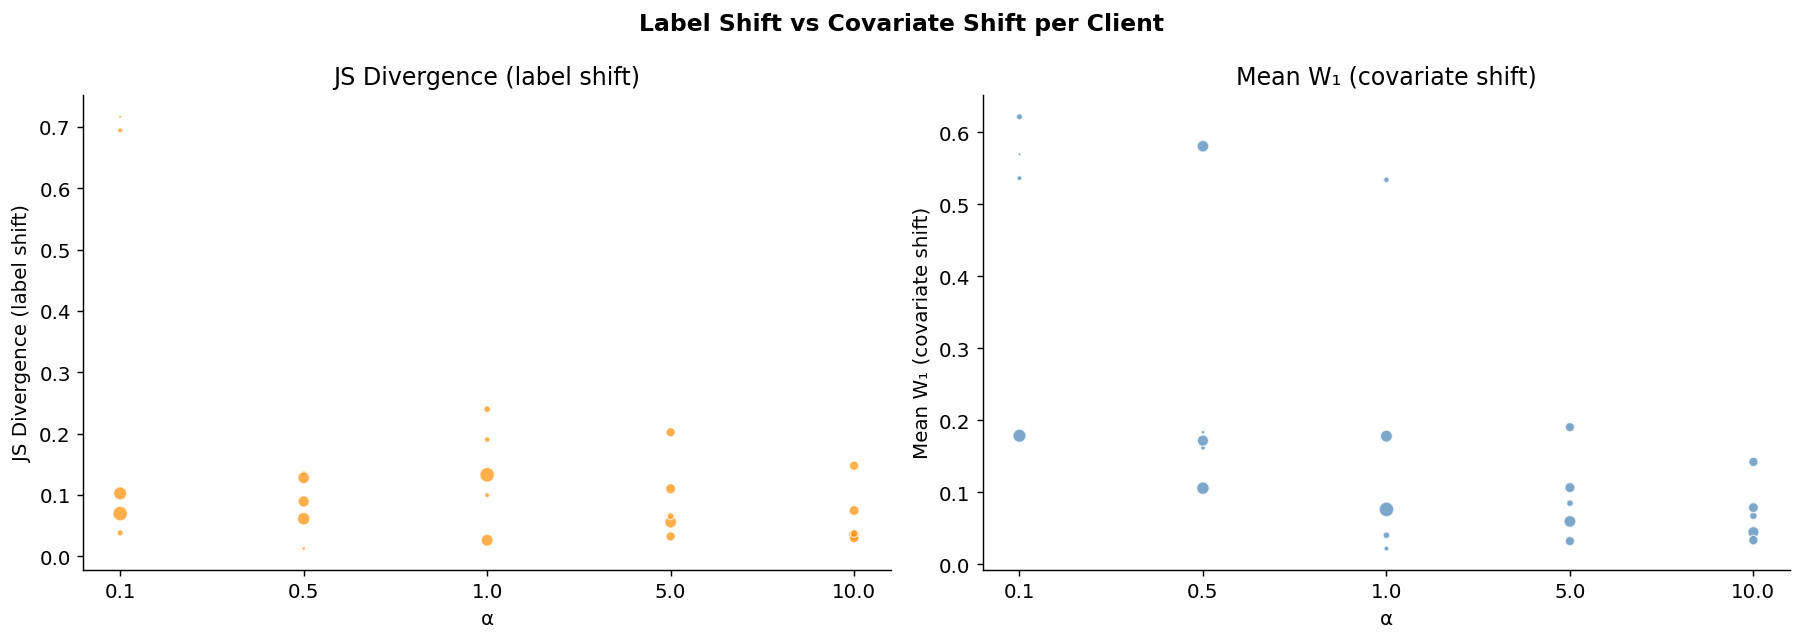

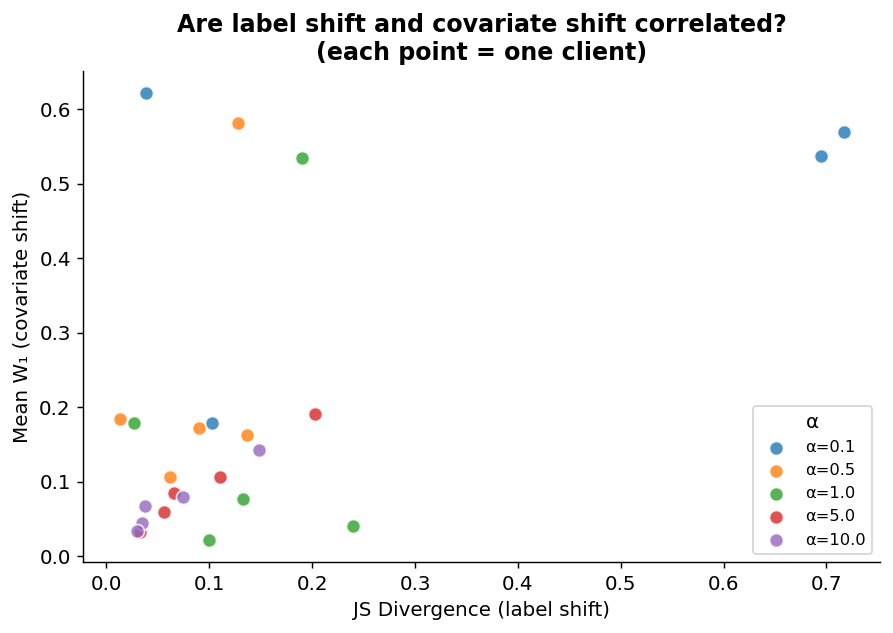

       js_divergence  mean_w1
alpha                        
0.1           0.3246   0.4768
0.5           0.0857   0.2410
1.0           0.1381   0.1703
5.0           0.0935   0.0950
10.0          0.0650   0.0735


In [35]:
from scipy.spatial.distance import jensenshannon

# Global label distribution
global_label_dist = np.array([1 - y.mean(), y.mean()])  # [P(y=0), P(y=1)]

js_records = []

for alpha, partition in filtered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        
        # Client label distribution
        client_labels = [patient_labels_map.get(p, 0) for p in pid_set]
        n_pos = sum(client_labels)
        n_total = len(client_labels)
        client_label_dist = np.array([(n_total - n_pos) / n_total, n_pos / n_total])
        
        # Jensen-Shannon divergence (base-2 → range [0, 1])
        js = jensenshannon(global_label_dist, client_label_dist, base=2)
        
        # Mean W1 for this client (covariate shift)
        client_w1 = wass_df[
            (wass_df['alpha'] == alpha) & (wass_df['client'] == f'C{client_id}')
        ]['wasserstein'].mean()
        
        js_records.append({
            'alpha': alpha,
            'client': f'C{client_id}',
            'js_divergence': js,
            'mean_w1': client_w1,
            'pos_rate': n_pos / n_total,
            'n_patients': n_total
        })

js_df = pd.DataFrame(js_records)

# ── Plot: JS (label shift) vs W1 (covariate shift) side by side ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label Shift vs Covariate Shift per Client', fontweight='bold', fontsize=13)

for ax, (metric, label, color) in zip(axes, [
    ('js_divergence', 'JS Divergence (label shift)',   'darkorange'),
    ('mean_w1',       'Mean W₁ (covariate shift)',     'steelblue'),
]):
    for alpha in ALPHA_SWEEP:
        sub = js_df[js_df['alpha'] == alpha]
        if sub.empty:
            continue
        ax.scatter(
            [str(alpha)] * len(sub), sub[metric],
            s=sub['n_patients'] / 500,   # bubble size = client size
            alpha=0.7, color=color, edgecolors='white', linewidth=0.8
        )
    ax.set_xlabel('α')
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('figures/11_label_vs_covariate_shift.png', bbox_inches='tight')
plt.show()

# ── Scatter: does label shift correlate with covariate shift? ─────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for alpha in ALPHA_SWEEP:
    sub = js_df[js_df['alpha'] == alpha]
    ax.scatter(sub['js_divergence'], sub['mean_w1'],
               label=f'α={alpha}', s=60, alpha=0.8, edgecolors='white')

ax.set_xlabel('JS Divergence (label shift)')
ax.set_ylabel('Mean W₁ (covariate shift)')
ax.set_title('Are label shift and covariate shift correlated?\n'
             '(each point = one client)', fontweight='bold')
ax.legend(title='α', fontsize=9)
plt.tight_layout()
plt.savefig('figures/12_shift_correlation.png', bbox_inches='tight')
plt.show()

print(js_df.groupby('alpha')[['js_divergence', 'mean_w1']].mean().round(4))

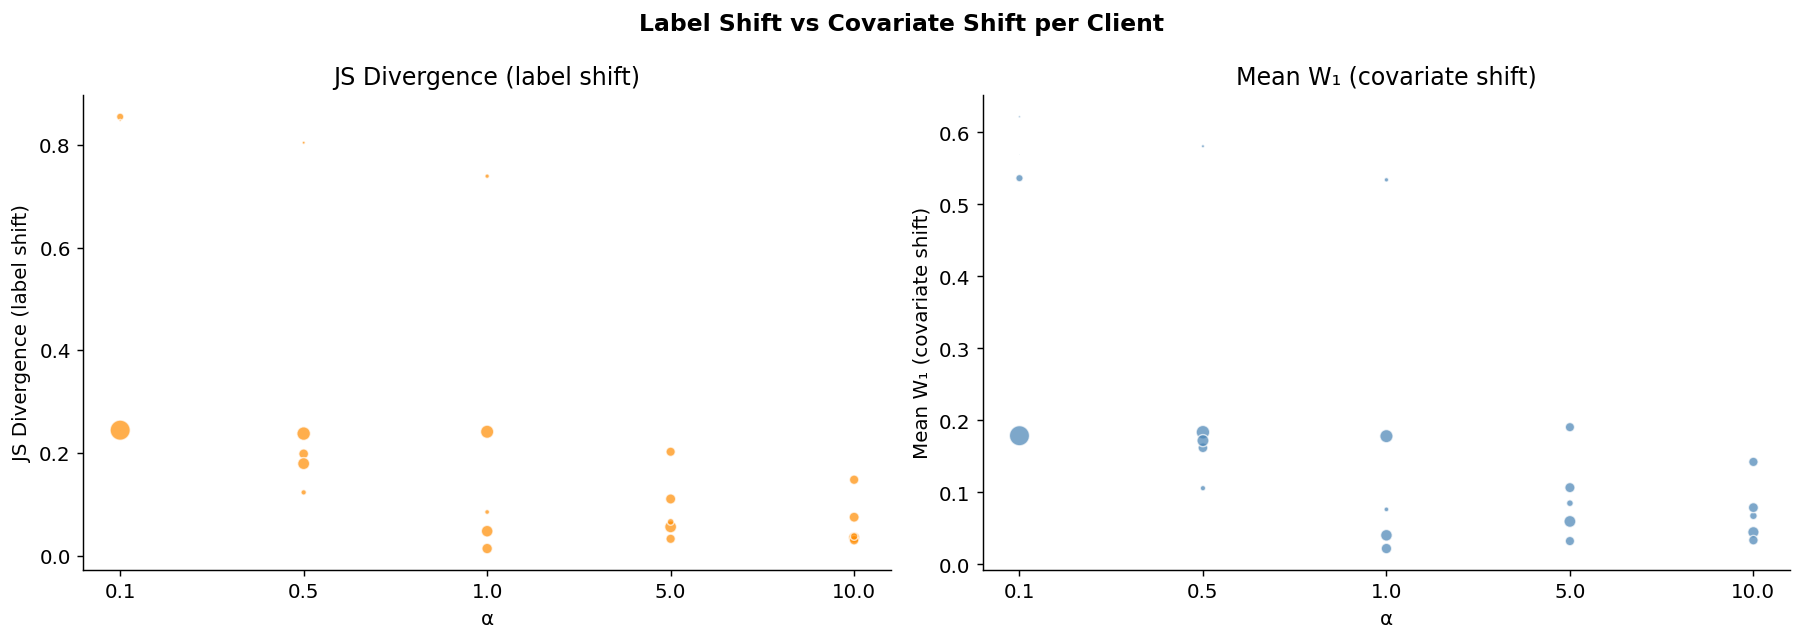

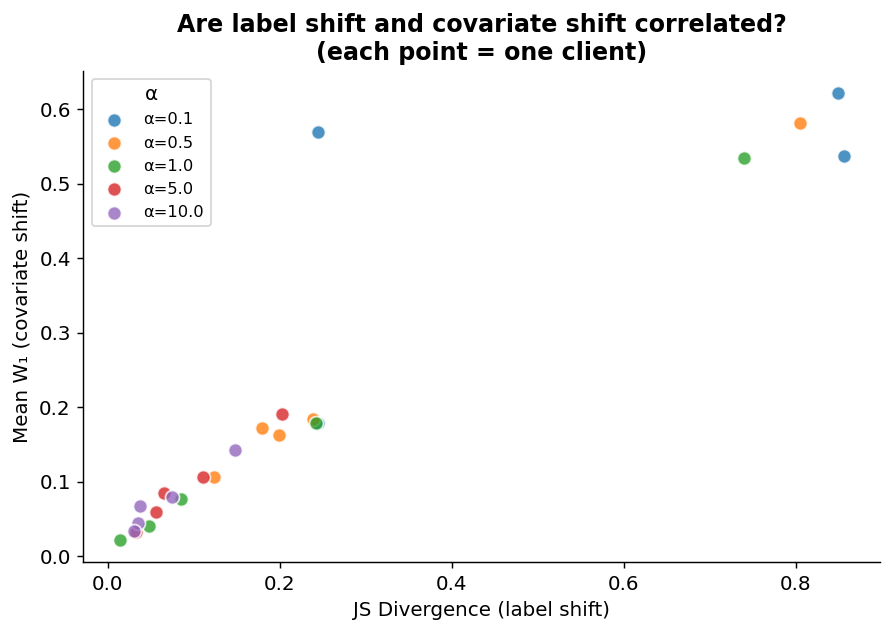

       js_divergence  mean_w1
alpha                        
0.1           0.4875   0.4768
0.5           0.3088   0.2410
1.0           0.2255   0.1703
5.0           0.0935   0.0950
10.0          0.0650   0.0735


In [36]:
from scipy.spatial.distance import jensenshannon

# Global label distribution
global_label_dist = np.array([1 - y.mean(), y.mean()])  # [P(y=0), P(y=1)]

js_records = []

for alpha, partition in unfiltered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        
        # Client label distribution
        client_labels = [patient_labels_map.get(p, 0) for p in pid_set]
        n_pos = sum(client_labels)
        n_total = len(client_labels)
        client_label_dist = np.array([(n_total - n_pos) / n_total, n_pos / n_total])
        
        # Jensen-Shannon divergence (base-2 → range [0, 1])
        js = jensenshannon(global_label_dist, client_label_dist, base=2)
        
        # Mean W1 for this client (covariate shift)
        client_w1 = wass_df[
            (wass_df['alpha'] == alpha) & (wass_df['client'] == f'C{client_id}')
        ]['wasserstein'].mean()
        
        js_records.append({
            'alpha': alpha,
            'client': f'C{client_id}',
            'js_divergence': js,
            'mean_w1': client_w1,
            'pos_rate': n_pos / n_total,
            'n_patients': n_total
        })

js_df = pd.DataFrame(js_records)

# ── Plot: JS (label shift) vs W1 (covariate shift) side by side ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label Shift vs Covariate Shift per Client', fontweight='bold', fontsize=13)

for ax, (metric, label, color) in zip(axes, [
    ('js_divergence', 'JS Divergence (label shift)',   'darkorange'),
    ('mean_w1',       'Mean W₁ (covariate shift)',     'steelblue'),
]):
    for alpha in ALPHA_SWEEP:
        sub = js_df[js_df['alpha'] == alpha]
        if sub.empty:
            continue
        ax.scatter(
            [str(alpha)] * len(sub), sub[metric],
            s=sub['n_patients'] / 500,   # bubble size = client size
            alpha=0.7, color=color, edgecolors='white', linewidth=0.8
        )
    ax.set_xlabel('α')
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.savefig('figures/11_label_vs_covariate_shift.png', bbox_inches='tight')
plt.show()

# ── Scatter: does label shift correlate with covariate shift? ─────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for alpha in ALPHA_SWEEP:
    sub = js_df[js_df['alpha'] == alpha]
    ax.scatter(sub['js_divergence'], sub['mean_w1'],
               label=f'α={alpha}', s=60, alpha=0.8, edgecolors='white')

ax.set_xlabel('JS Divergence (label shift)')
ax.set_ylabel('Mean W₁ (covariate shift)')
ax.set_title('Are label shift and covariate shift correlated?\n'
             '(each point = one client)', fontweight='bold')
ax.legend(title='α', fontsize=9)
plt.tight_layout()
plt.savefig('figures/12_shift_correlation.png', bbox_inches='tight')
plt.show()

print(js_df.groupby('alpha')[['js_divergence', 'mean_w1']].mean().round(4))

## 10. Distribution of W1 Across Clients

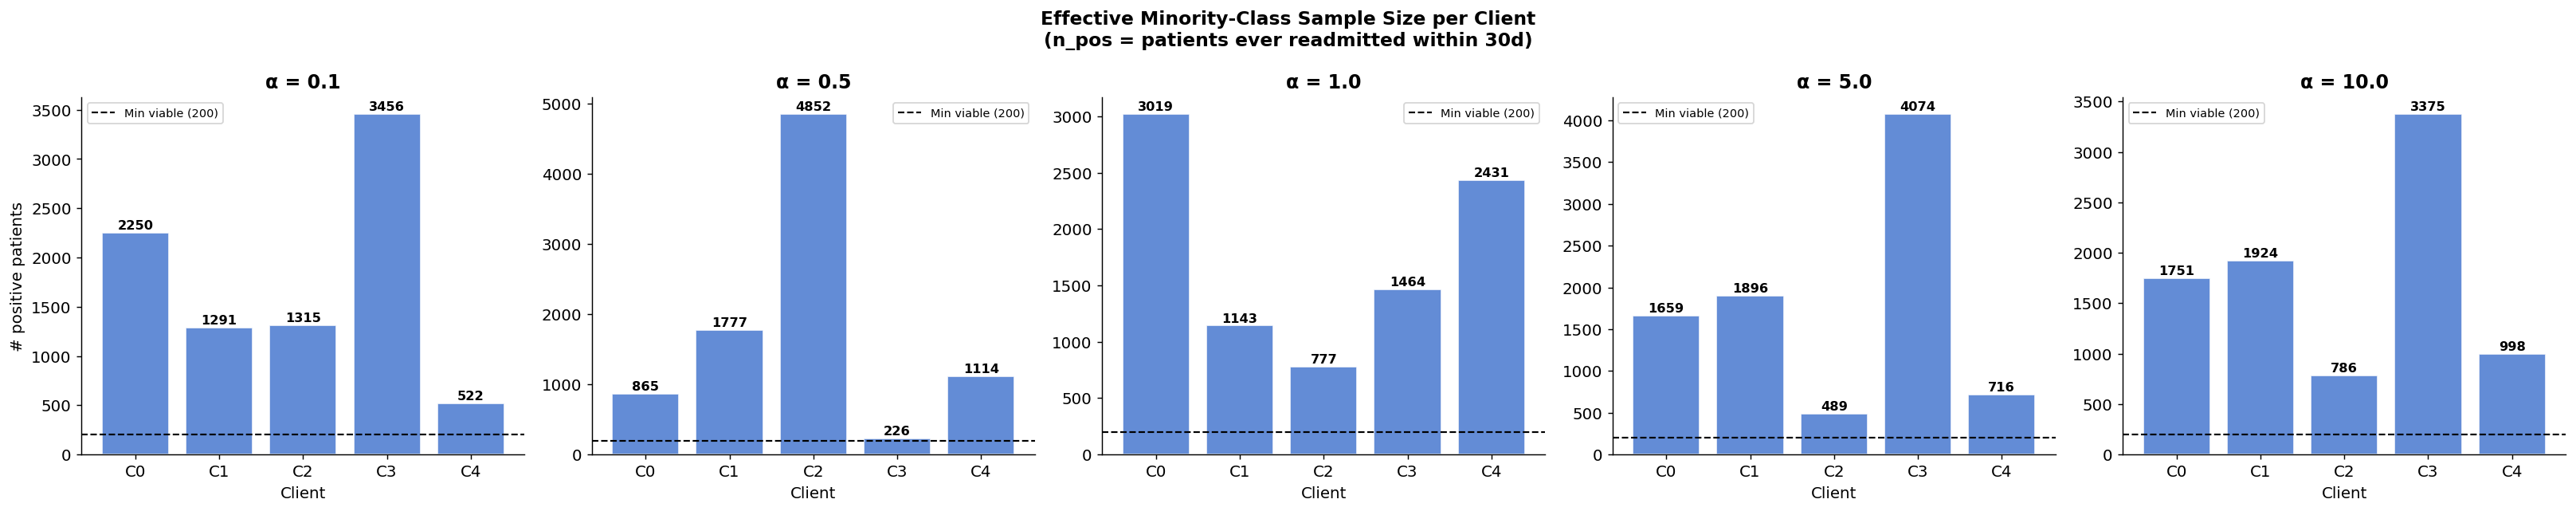

Effective minority-class sample size per client:

alpha   0.1   0.5   1.0   5.0   10.0
client                              
C0      2250   865  3019  1659  1751
C1      1291  1777  1143  1896  1924
C2      1315  4852   777   489   786
C3      3456   226  1464  4074  3375
C4       522  1114  2431   716   998

Clients below 200 positive samples (unreliable local learning):
Empty DataFrame
Columns: [alpha, client, n_pos, pos_rate]
Index: []


In [37]:
eff_records = []

for alpha, partition in filtered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        client_labels = [patient_labels_map.get(p, 0) for p in pid_set]
        n_total   = len(client_labels)
        n_pos     = sum(client_labels)
        n_neg     = n_total - n_pos
        pos_rate  = n_pos / n_total if n_total > 0 else 0

        eff_records.append({
            'alpha':    alpha,
            'client':   f'C{client_id}',
            'n_total':  n_total,
            'n_pos':    n_pos,           # effective minority-class size
            'n_neg':    n_neg,
            'pos_rate': pos_rate,
        })

eff_df = pd.DataFrame(eff_records)

# ── Plot n_pos per client across alpha values ──────────────────────────────────
fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 5), sharey=False)
fig.suptitle('Effective Minority-Class Sample Size per Client\n'
             '(n_pos = patients ever readmitted within 30d)',
             fontweight='bold', fontsize=13)

# Reference: minimum viable sample size for learning
MIN_VIABLE = 200

for ax, alpha in zip(axes, ALPHA_SWEEP):
    sub = eff_df[eff_df['alpha'] == alpha].sort_values('client')
    colors = ['#E24A33' if n < MIN_VIABLE else '#4878CF' for n in sub['n_pos']]
    
    bars = ax.bar(sub['client'], sub['n_pos'], color=colors,
                  alpha=0.85, edgecolor='white')
    
    ax.axhline(MIN_VIABLE, color='black', linestyle='--', linewidth=1.2,
               label=f'Min viable ({MIN_VIABLE})')
    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_ylabel('# positive patients' if alpha == ALPHA_SWEEP[0] else '')
    ax.set_xlabel('Client')
    ax.legend(fontsize=8)
    
    for bar, n in zip(bars, sub['n_pos']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1] * 0.01,
                str(int(n)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/14_effective_minority_size.png', bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print('Effective minority-class sample size per client:\n')
pivot = eff_df.pivot(index='client', columns='alpha', values='n_pos').astype(int)
print(pivot.to_string())
print(f'\nClients below {MIN_VIABLE} positive samples (unreliable local learning):')
print(eff_df[eff_df['n_pos'] < MIN_VIABLE][['alpha','client','n_pos','pos_rate']].to_string(index=False))

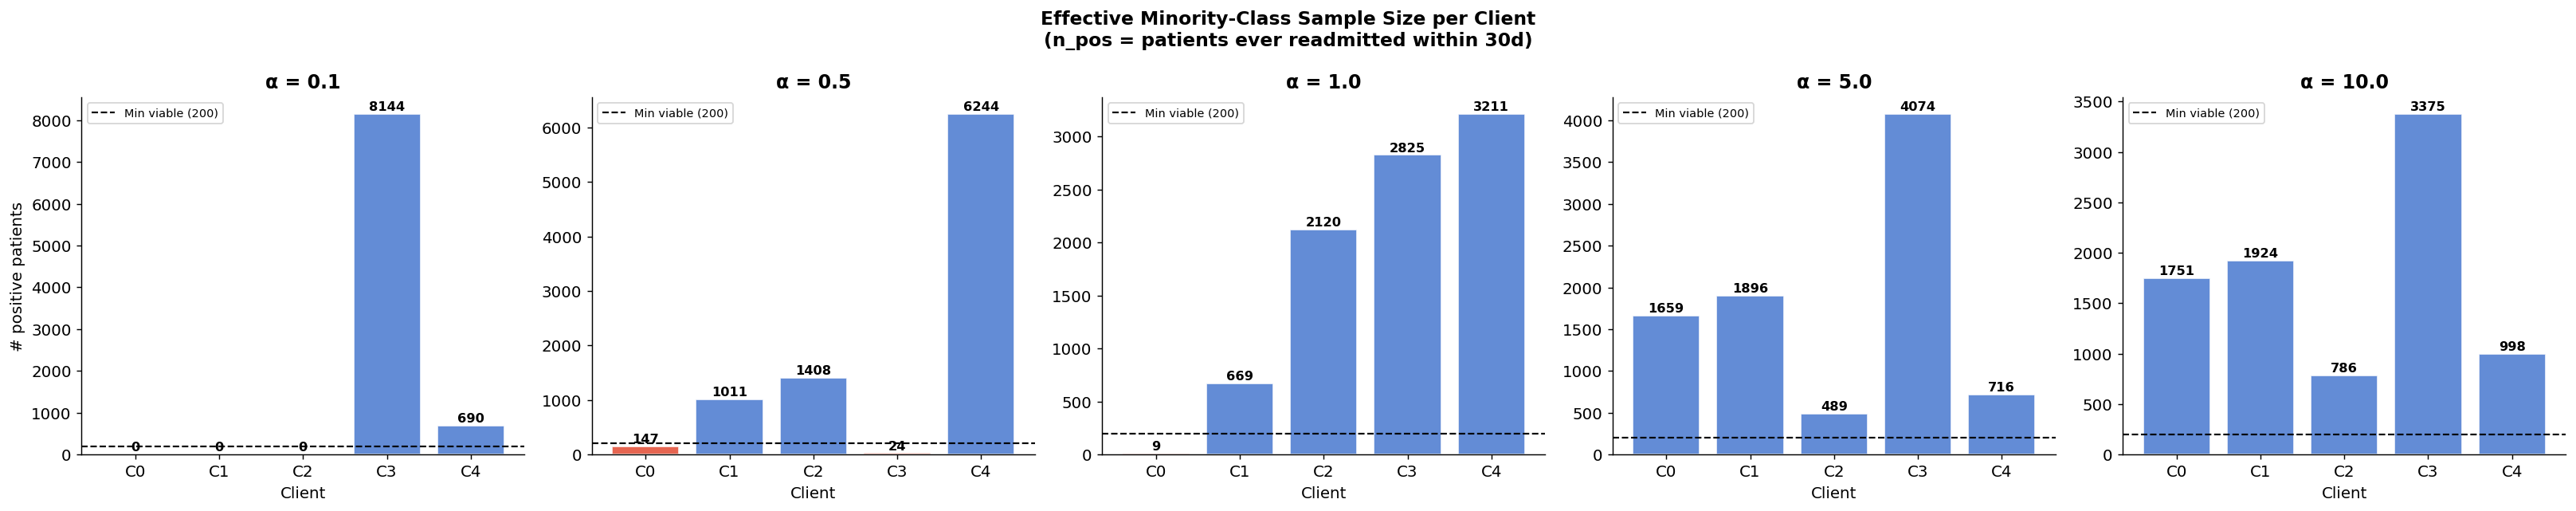

Effective minority-class sample size per client:

alpha   0.1   0.5   1.0   5.0   10.0
client                              
C0         0   147     9  1659  1751
C1         0  1011   669  1896  1924
C2         0  1408  2120   489   786
C3      8144    24  2825  4074  3375
C4       690  6244  3211   716   998

Clients below 200 positive samples (unreliable local learning):
 alpha client  n_pos  pos_rate
   0.1     C0      0  0.000000
   0.1     C1      0  0.000000
   0.1     C2      0  0.000000
   0.5     C0    147  0.009936
   0.5     C3     24  0.000843
   1.0     C0      9  0.000335


In [38]:
eff_records = []

for alpha, partition in unfiltered_partitions.items():
    for client_id, patient_ids in partition.items():
        pid_set = set(patient_ids)
        client_labels = [patient_labels_map.get(p, 0) for p in pid_set]
        n_total   = len(client_labels)
        n_pos     = sum(client_labels)
        n_neg     = n_total - n_pos
        pos_rate  = n_pos / n_total if n_total > 0 else 0

        eff_records.append({
            'alpha':    alpha,
            'client':   f'C{client_id}',
            'n_total':  n_total,
            'n_pos':    n_pos,           # effective minority-class size
            'n_neg':    n_neg,
            'pos_rate': pos_rate,
        })

eff_df = pd.DataFrame(eff_records)

# ── Plot n_pos per client across alpha values ──────────────────────────────────
fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 5), sharey=False)
fig.suptitle('Effective Minority-Class Sample Size per Client\n'
             '(n_pos = patients ever readmitted within 30d)',
             fontweight='bold', fontsize=13)

# Reference: minimum viable sample size for learning
MIN_VIABLE = 200

for ax, alpha in zip(axes, ALPHA_SWEEP):
    sub = eff_df[eff_df['alpha'] == alpha].sort_values('client')
    colors = ['#E24A33' if n < MIN_VIABLE else '#4878CF' for n in sub['n_pos']]
    
    bars = ax.bar(sub['client'], sub['n_pos'], color=colors,
                  alpha=0.85, edgecolor='white')
    
    ax.axhline(MIN_VIABLE, color='black', linestyle='--', linewidth=1.2,
               label=f'Min viable ({MIN_VIABLE})')
    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_ylabel('# positive patients' if alpha == ALPHA_SWEEP[0] else '')
    ax.set_xlabel('Client')
    ax.legend(fontsize=8)
    
    for bar, n in zip(bars, sub['n_pos']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1] * 0.01,
                str(int(n)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/14_effective_minority_size.png', bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print('Effective minority-class sample size per client:\n')
pivot = eff_df.pivot(index='client', columns='alpha', values='n_pos').astype(int)
print(pivot.to_string())
print(f'\nClients below {MIN_VIABLE} positive samples (unreliable local learning):')
print(eff_df[eff_df['n_pos'] < MIN_VIABLE][['alpha','client','n_pos','pos_rate']].to_string(index=False))


─────────────────────────────────────────────────────────────────
  α=0.1 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     28,959    5,040    8,482         99      0.068
  client_1      2,472      470      754         99      0.437
  client_2     22,830    4,088    6,748         99      0.050
  client_3      6,799    1,212    2,059         99      0.432
  client_4      5,401      930    1,581         99      0.090


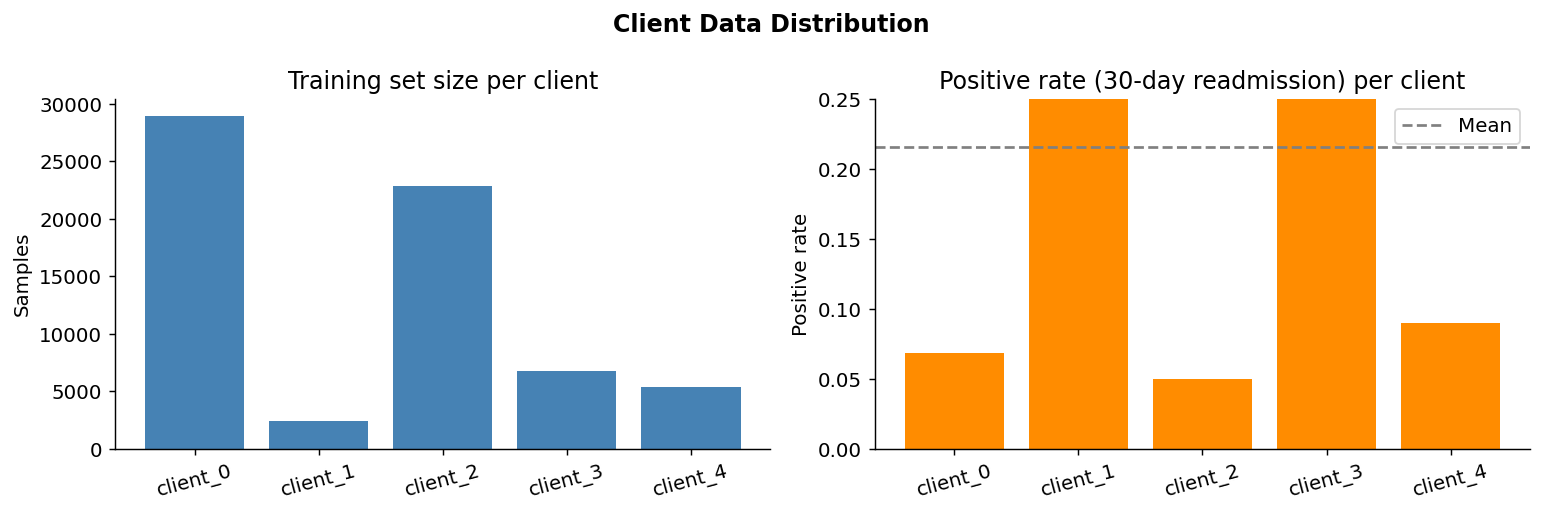


─────────────────────────────────────────────────────────────────
  α=0.5 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0      3,802      687    1,169         99      0.184
  client_1     21,345    3,688    6,378         99      0.073
  client_2     22,298    3,938    6,548         99      0.188
  client_3      2,004      356      566         99      0.100
  client_4     17,021    3,041    4,984         99      0.056


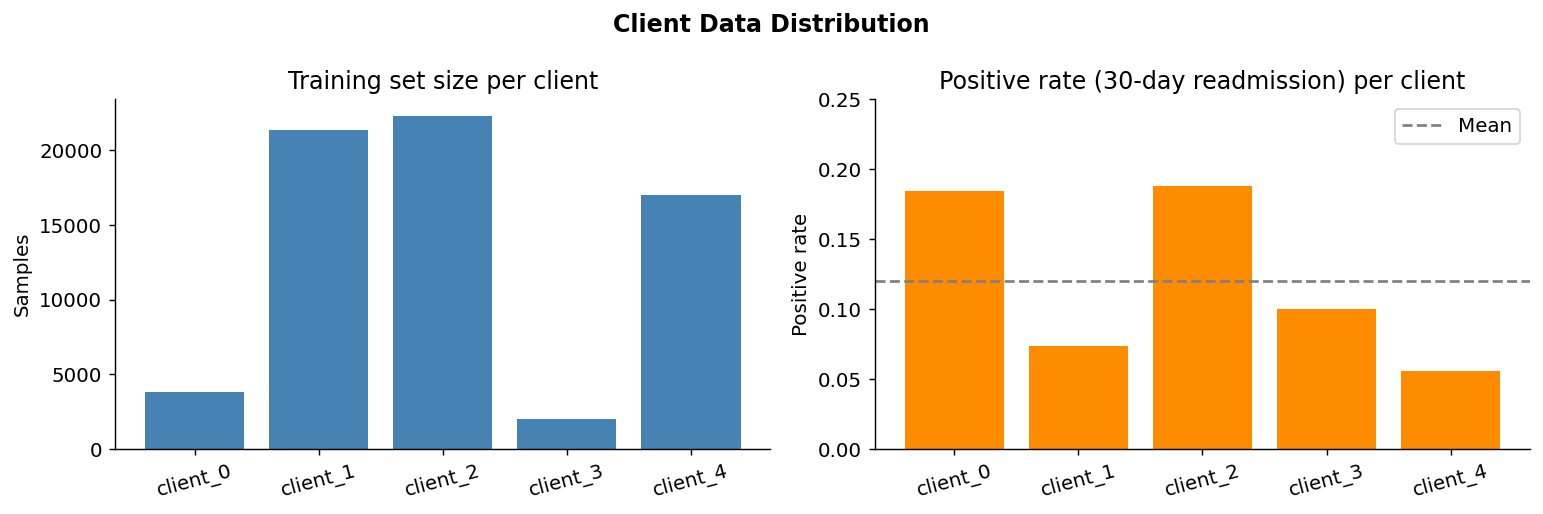


─────────────────────────────────────────────────────────────────
  α=1.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     21,064    3,655    6,157         99      0.121
  client_1     27,677    4,916    8,226         99      0.035
  client_2      3,855      746    1,189         99      0.160
  client_3      5,566      985    1,664         99      0.231
  client_4      8,208    1,546    2,371         99      0.256


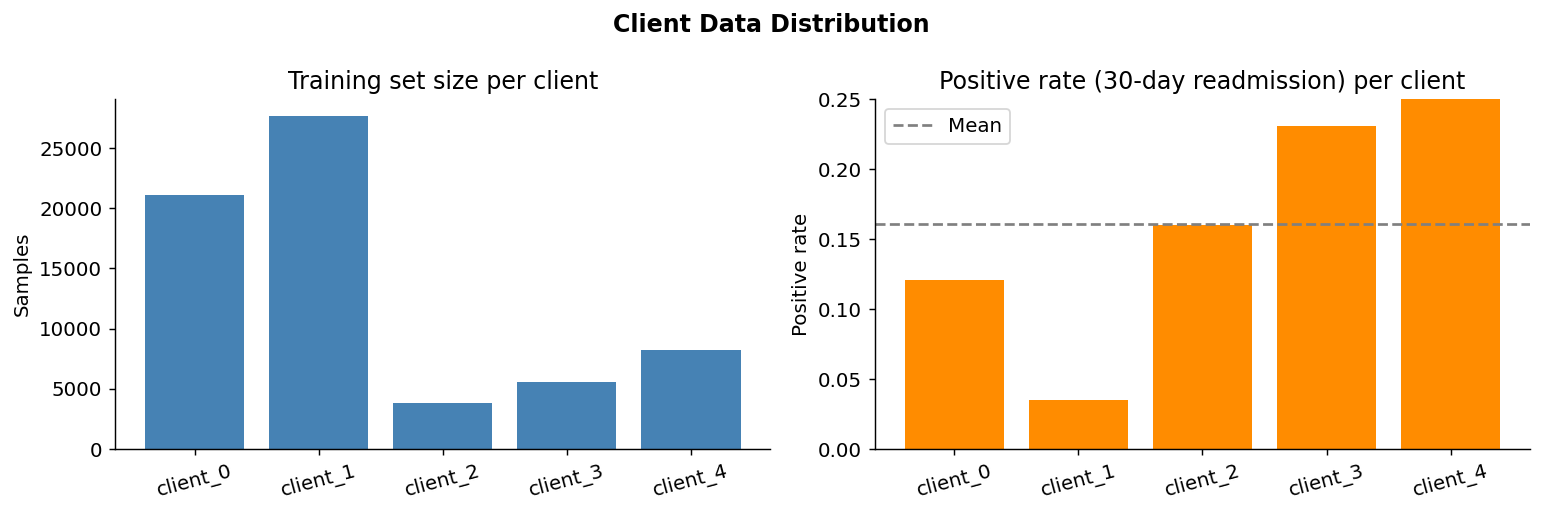


─────────────────────────────────────────────────────────────────
  α=5.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     19,258    3,385    5,686         99      0.075
  client_1     12,850    2,237    3,714         99      0.130
  client_2      6,047    1,078    1,807         99      0.068
  client_3     14,960    2,624    4,371         99      0.236
  client_4     13,463    2,336    4,009         99      0.042


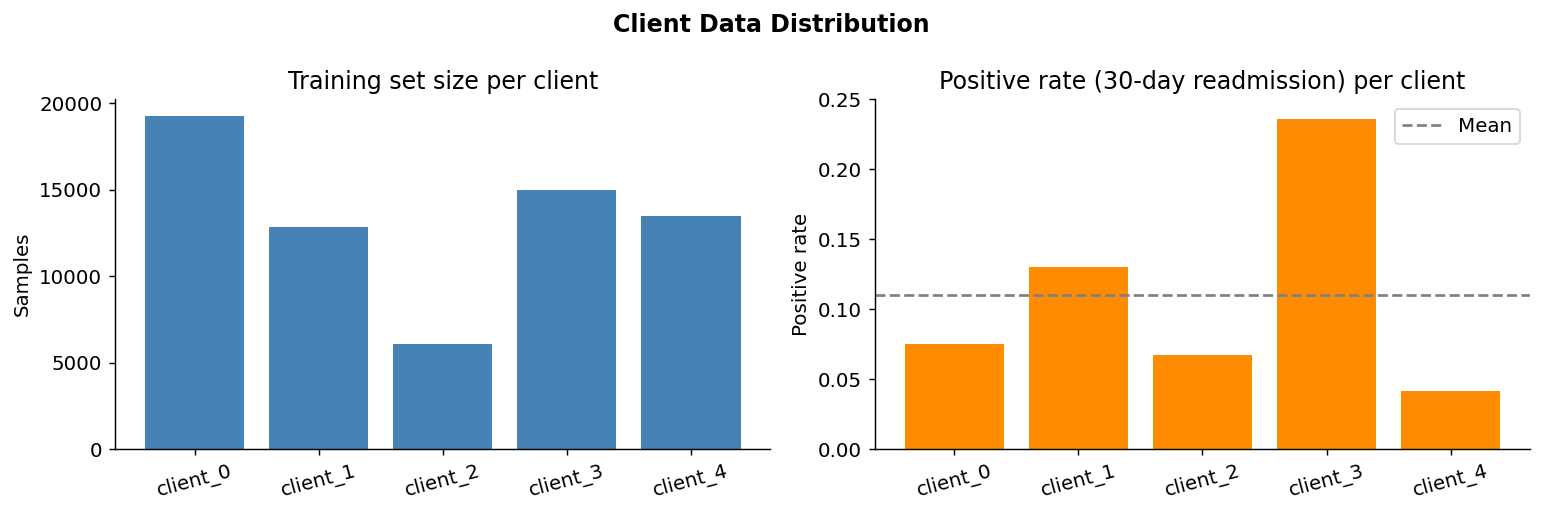


─────────────────────────────────────────────────────────────────
  α=10.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     17,567    3,129    5,147         99      0.089
  client_1     13,174    2,357    3,776         99      0.126
  client_2      7,936    1,355    2,341         99      0.087
  client_3     14,415    2,526    4,304         99      0.201
  client_4     13,517    2,370    3,911         99      0.064


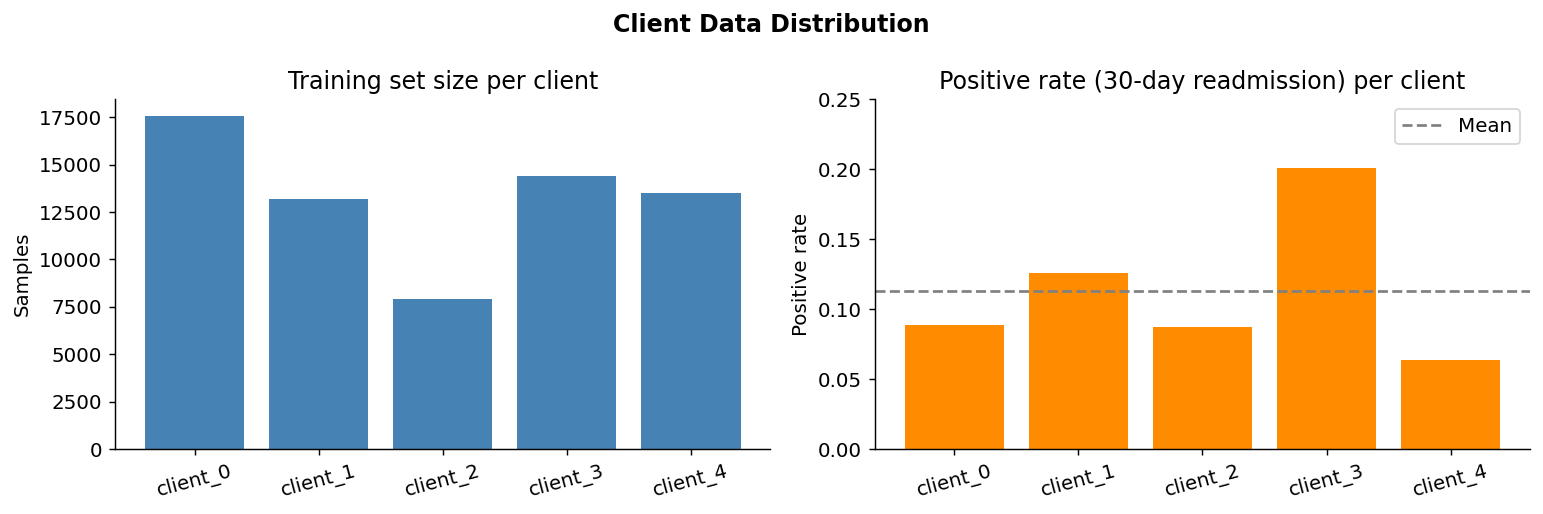

In [40]:
for alpha in ALPHA_SWEEP: 

    print(f'\n{"─" * 65}')
    print(f'  α={alpha} client data summary:')
    print(f'  {"Client":<10} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10} {"Pos. rate":>10}')
    print(f'  {"─"*10} {"─"*8} {"─"*8} {"─"*8} {"─"*10} {"─"*10}')
    client_info = {}

    for i in range(N_CLIENTS):
        client_dir = os.path.join(FILTERED_DIR, f'alpha_{alpha}', f'client_{i}')
        with open(os.path.join(client_dir, 'client_info.json'), 'r') as f:
            client_info[f'client_{i}'] = json.load(f)
            

    for k, v in client_info.items():
        print(f'  {k:<10} {v["n_train"]:>8,} {v["n_val"]:>8,} '
            f'{v["n_test"]:>8,} {v["n_features"]:>10,} {v["positive_rate"]:>10.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Client Data Distribution', fontweight='bold')

    clients_keys     = list(client_info.keys())
    train_sizes = [client_info[c]['n_train'] for c in clients_keys]
    pos_rates   = [client_info[c]['positive_rate'] for c in clients_keys]

    axes[0].bar(clients_keys, train_sizes, color='steelblue')
    axes[0].set_title('Training set size per client')
    axes[0].set_ylabel('Samples')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(clients_keys, pos_rates, color='darkorange')
    axes[1].axhline(sum(pos_rates) / len(pos_rates), color='gray',
                    linestyle='--', label='Mean')
    axes[1].set_title('Positive rate (30-day readmission) per client')
    axes[1].set_ylabel('Positive rate')
    axes[1].set_ylim(0, 0.25)
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FILTERED_DIR, 'client_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()


─────────────────────────────────────────────────────────────────
  α=0.1 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0          2        1        1         99      0.000
  client_1         14        3        4         99      0.000
  client_2     50,082    8,864   14,544         99      0.000
  client_3     15,085    2,693    4,536         99      0.465
  client_4      1,370      230      396         99      0.437


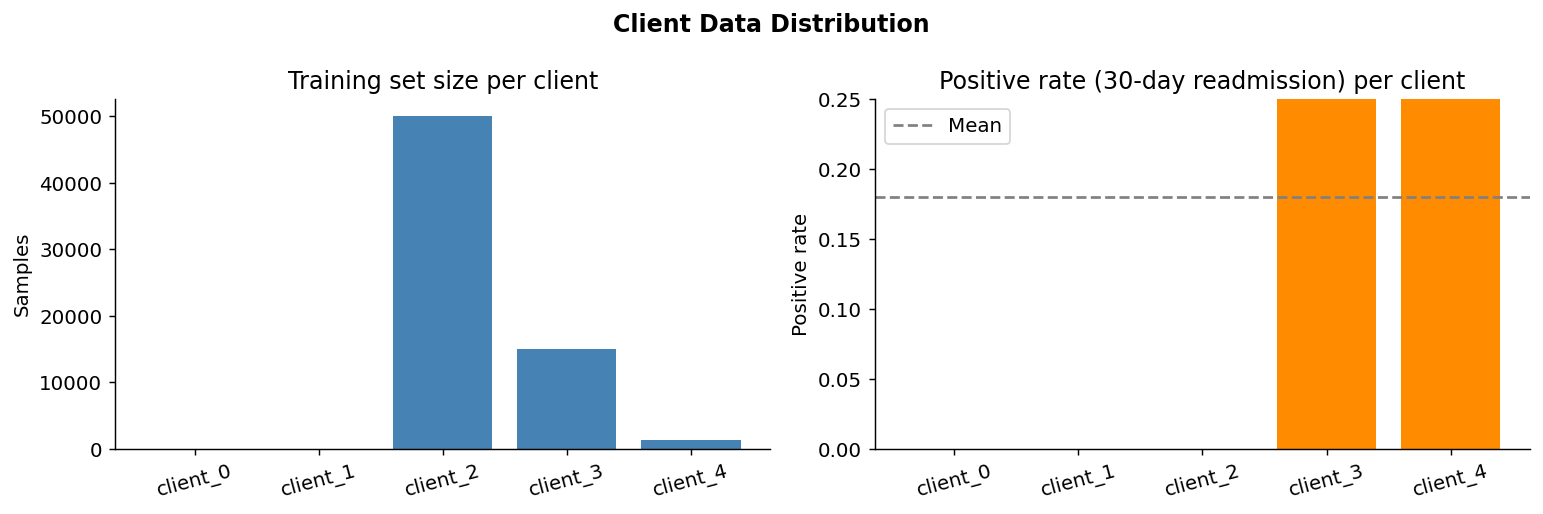


─────────────────────────────────────────────────────────────────
  α=0.5 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     11,874    2,088    3,614         99      0.011
  client_1      4,709      869    1,377         99      0.184
  client_2      2,652      459      767         99      0.454
  client_3     22,704    3,981    6,660         99      0.001
  client_4     24,591    4,273    7,207         99      0.221


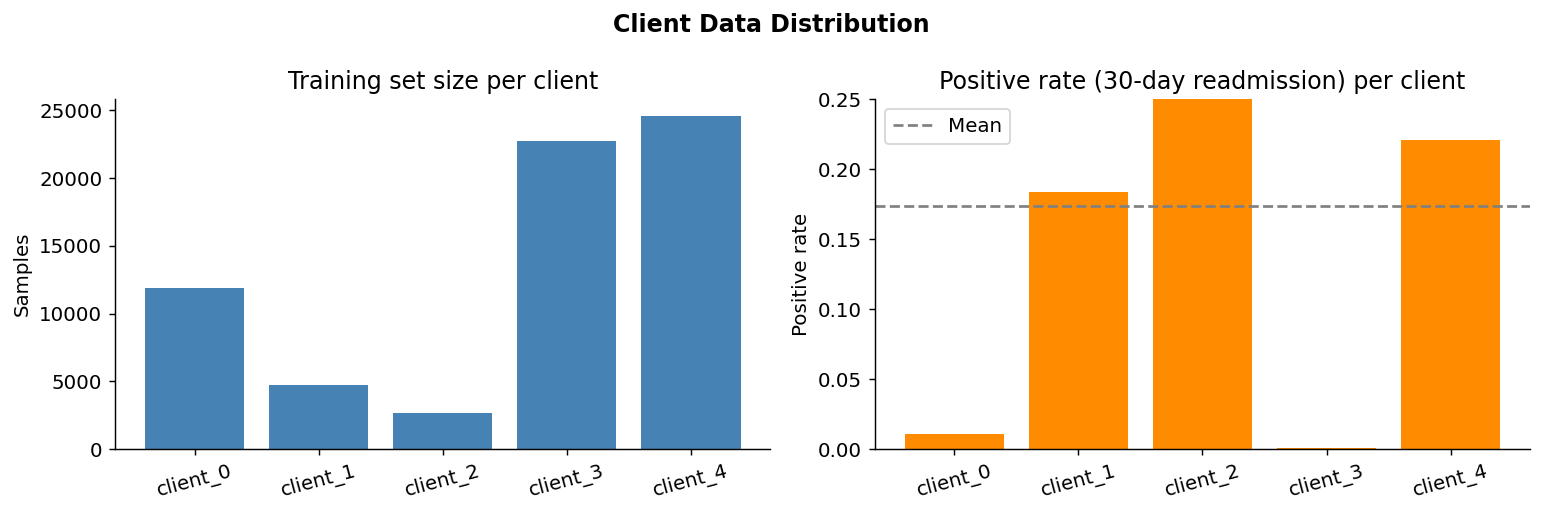


─────────────────────────────────────────────────────────────────
  α=1.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     21,461    3,750    6,363         99      0.000
  client_1      3,512      631    1,046         99      0.166
  client_2     15,745    2,829    4,623         99      0.117
  client_3      5,596      920    1,591         99      0.439
  client_4     20,161    3,501    6,096         99      0.137


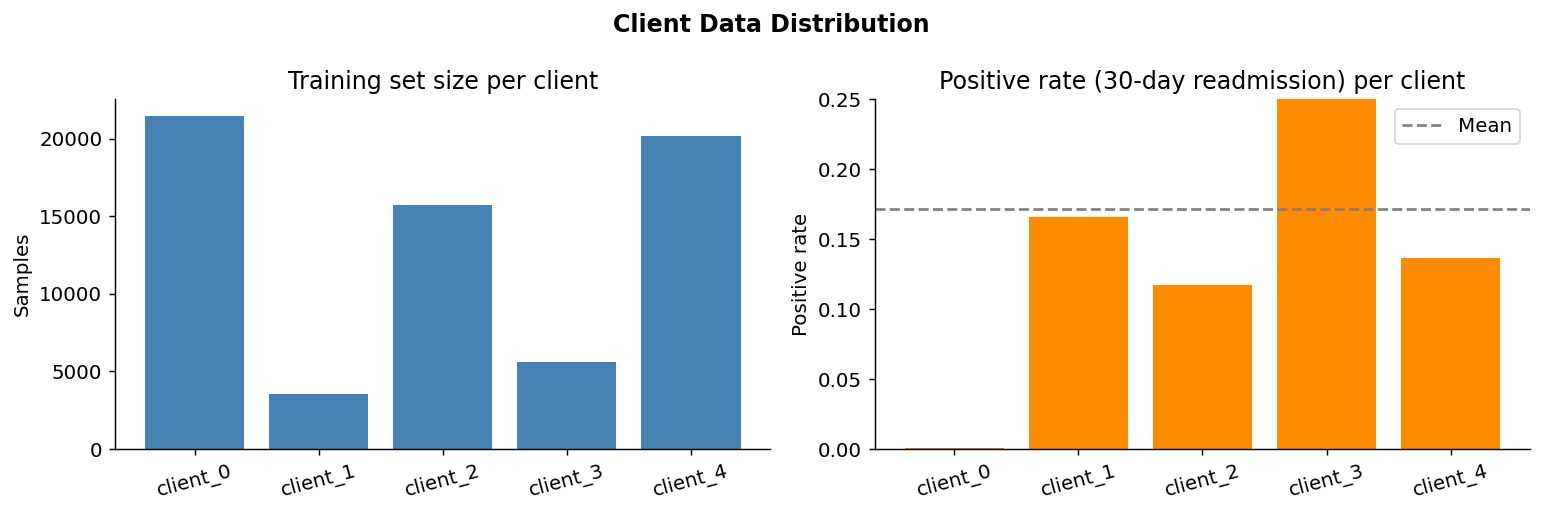


─────────────────────────────────────────────────────────────────
  α=5.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     19,258    3,385    5,686         99      0.075
  client_1     12,850    2,237    3,714         99      0.130
  client_2      6,047    1,078    1,807         99      0.068
  client_3     14,960    2,624    4,371         99      0.236
  client_4     13,463    2,336    4,009         99      0.042


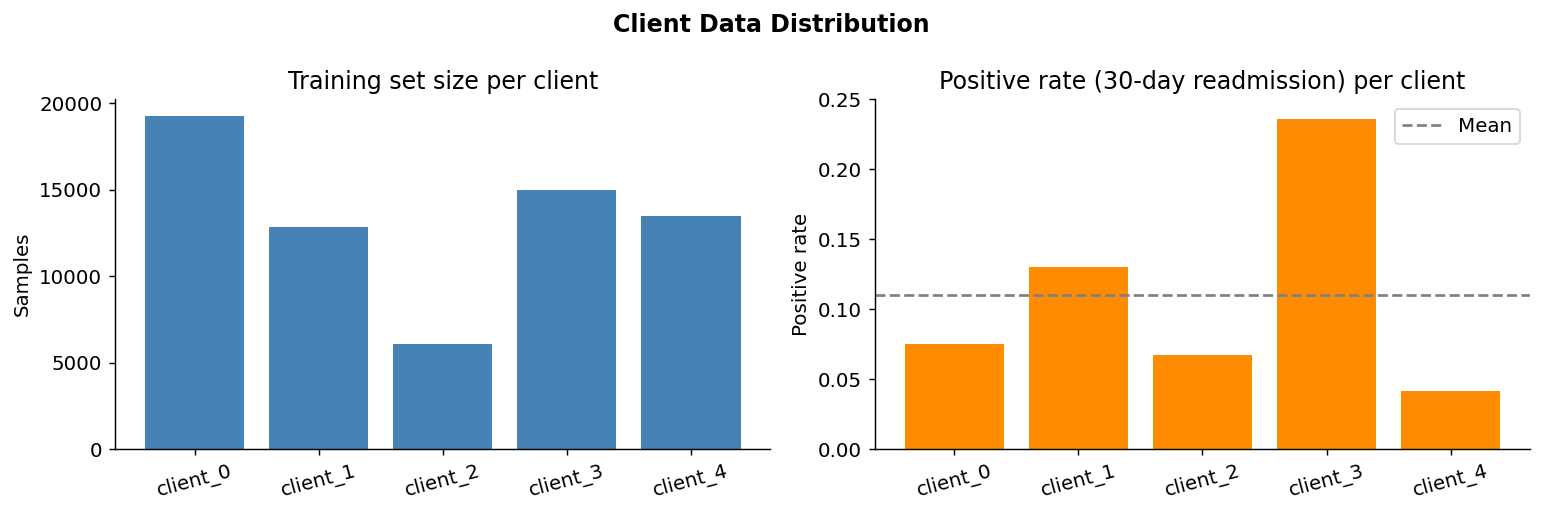


─────────────────────────────────────────────────────────────────
  α=10.0 client data summary:
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     17,567    3,129    5,147         99      0.089
  client_1     13,174    2,357    3,776         99      0.126
  client_2      7,936    1,355    2,341         99      0.087
  client_3     14,415    2,526    4,304         99      0.201
  client_4     13,517    2,370    3,911         99      0.064


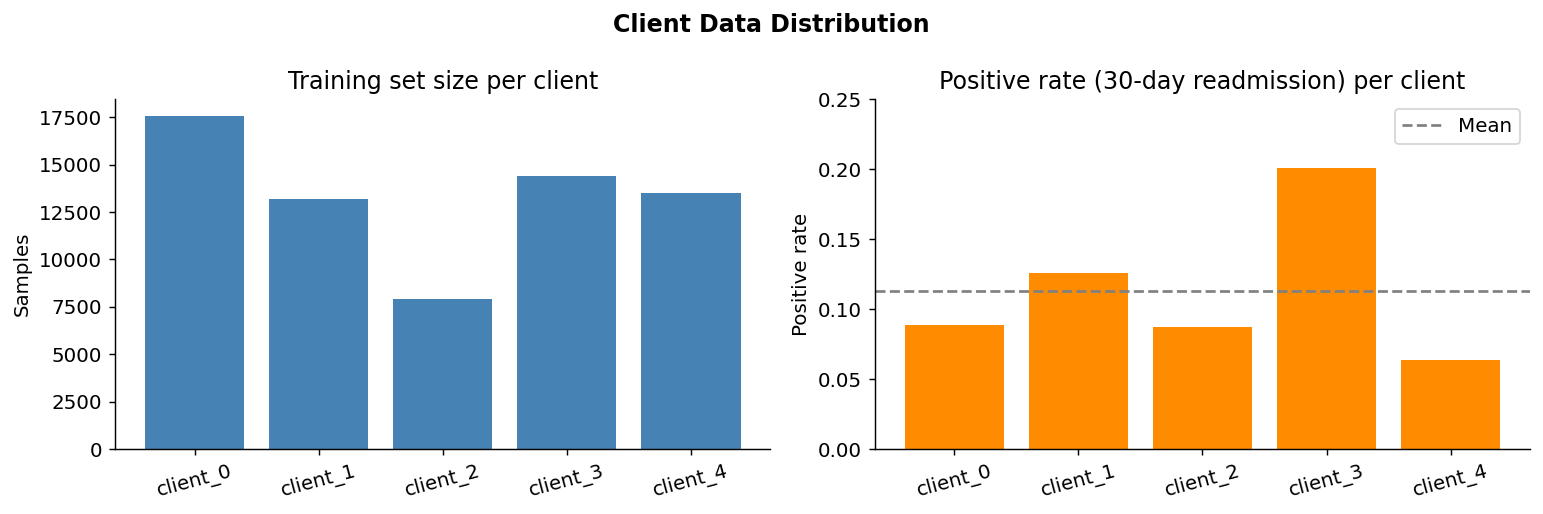

In [44]:
for alpha in ALPHA_SWEEP: 

    print(f'\n{"─" * 65}')
    print(f'  α={alpha} client data summary:')
    print(f'  {"Client":<10} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10} {"Pos. rate":>10}')
    print(f'  {"─"*10} {"─"*8} {"─"*8} {"─"*8} {"─"*10} {"─"*10}')
    client_info = {}

    for i in range(N_CLIENTS):
        client_dir = os.path.join(UNFILTERED_DIR, f'alpha_{alpha}', f'client_{i}')
        with open(os.path.join(client_dir, 'client_info.json'), 'r') as f:
            client_info[f'client_{i}'] = json.load(f)
            

    for k, v in client_info.items():
        print(f'  {k:<10} {v["n_train"]:>8,} {v["n_val"]:>8,} '
            f'{v["n_test"]:>8,} {v["n_features"]:>10,} {v["positive_rate"]:>10.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Client Data Distribution', fontweight='bold')

    clients_keys     = list(client_info.keys())
    train_sizes = [client_info[c]['n_train'] for c in clients_keys]
    pos_rates   = [client_info[c]['positive_rate'] for c in clients_keys]

    axes[0].bar(clients_keys, train_sizes, color='steelblue')
    axes[0].set_title('Training set size per client')
    axes[0].set_ylabel('Samples')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(clients_keys, pos_rates, color='darkorange')
    axes[1].axhline(sum(pos_rates) / len(pos_rates), color='gray',
                    linestyle='--', label='Mean')
    axes[1].set_title('Positive rate (30-day readmission) per client')
    axes[1].set_ylabel('Positive rate')
    axes[1].set_ylim(0, 0.25)
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(UNFILTERED_DIR, 'client_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Per-Client Label Prior Distortion (Impact on Generator's p^(y))

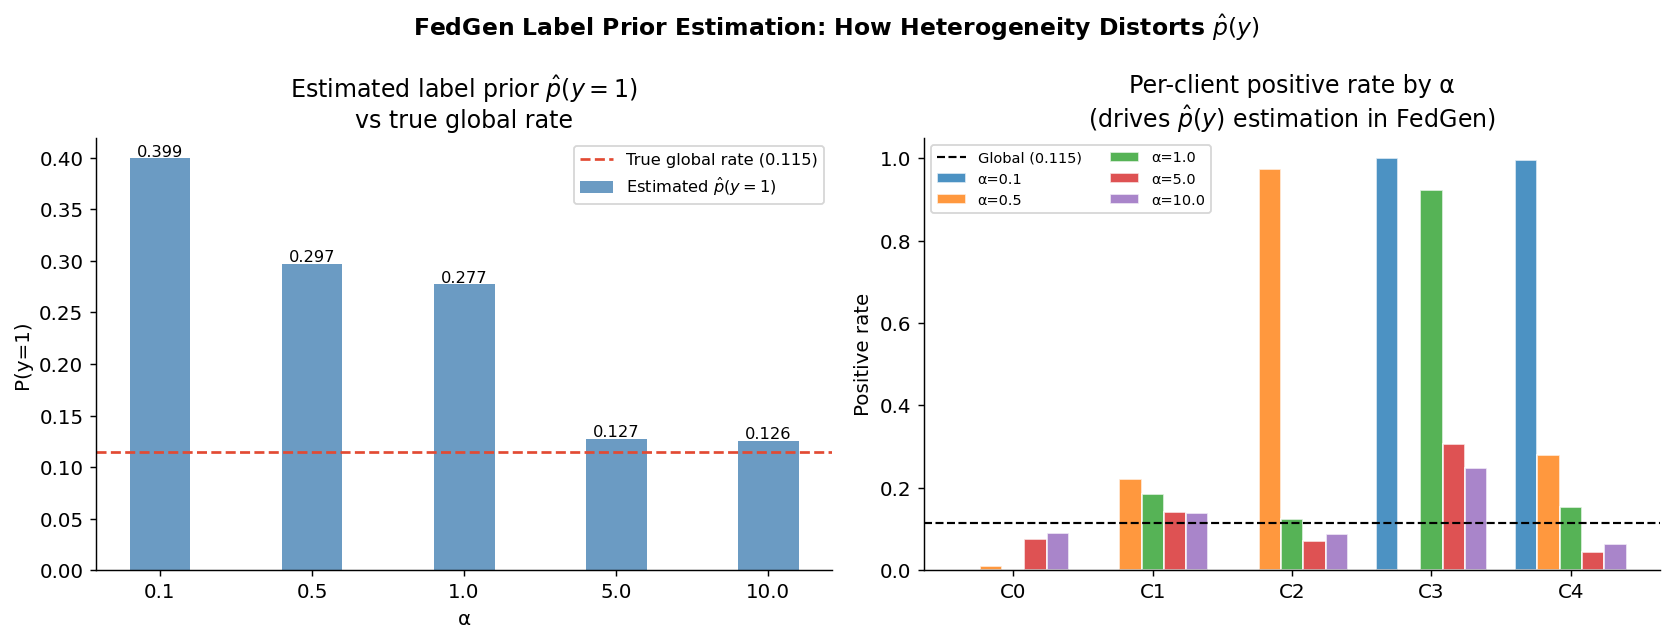


Label prior distortion summary:
 alpha  estimated_phat  true_rate  distortion
   0.1        0.399373   0.114562    0.284811
   0.5        0.297355   0.114562    0.182793
   1.0        0.277459   0.114562    0.162897
   5.0        0.127445   0.114562    0.012883
  10.0        0.125509   0.114562    0.010948


In [45]:
# Use only the alphas present in eff_df — avoids shape mismatch when
# some alphas from ALPHA_SWEEP were not found on disk (e.g. α=0.1).
available_alphas = sorted(eff_df['alpha'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("FedGen Label Prior Estimation: How Heterogeneity Distorts $\\hat{p}(y)$",
             fontweight='bold', fontsize=13)
true_pos_rate = y.mean()
prior_df = eff_df.groupby('alpha')['pos_rate'].mean().reset_index().rename(columns={'pos_rate': 'estimated_phat'})
prior_df['true_rate'] = true_pos_rate
prior_df['distortion'] = prior_df['estimated_phat'] - prior_df['true_rate']

# Left: estimated vs true prior per alpha
ax = axes[0]
plot_prior = prior_df[prior_df['alpha'].isin(available_alphas)].reset_index(drop=True)
ax.bar(plot_prior['alpha'].astype(str), plot_prior['estimated_phat'],
       color='steelblue', alpha=0.8, label='Estimated $\\hat{p}(y=1)$', width=0.4)
ax.axhline(true_pos_rate, color='#E24A33', linestyle='--', linewidth=1.5,
           label=f'True global rate ({true_pos_rate:.3f})')
ax.set_xlabel('α')
ax.set_ylabel('P(y=1)')
ax.set_title('Estimated label prior $\\hat{p}(y=1)$\nvs true global rate')
ax.legend(fontsize=9)
for i, row in plot_prior.iterrows():
    ax.text(i, row['estimated_phat'] + 0.002,
            f"{row['estimated_phat']:.3f}", ha='center', fontsize=9)

# Right: per-client positive rate vs global
ax = axes[1]
x     = np.arange(N_CLIENTS)
n_a   = len(available_alphas)
width = 0.8 / n_a   # divide bar group width evenly across available alphas

for i, alpha in enumerate(available_alphas):
    sub = eff_df[eff_df['alpha'] == alpha].sort_values('client').reset_index(drop=True)
    ax.bar(x + i * width, sub['pos_rate'], width=width,
           alpha=0.8, label=f'α={alpha}', edgecolor='white')

ax.axhline(true_pos_rate, color='black', linestyle='--',
           linewidth=1.2, label=f'Global ({true_pos_rate:.3f})')
ax.set_xticks(x + width * (n_a - 1) / 2)
ax.set_xticklabels([f'C{i}' for i in range(N_CLIENTS)])
ax.set_ylabel('Positive rate')
ax.set_title('Per-client positive rate by α\n(drives $\\hat{p}(y)$ estimation in FedGen)')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('figures/15_label_prior_distortion.png', bbox_inches='tight')
plt.show()

print('\nLabel prior distortion summary:')
print(plot_prior[['alpha', 'estimated_phat', 'true_rate', 'distortion']].to_string(index=False))

In [ ]:
# Use only the alphas present in eff_df — avoids shape mismatch when
# some alphas from ALPHA_SWEEP were not found on disk (e.g. α=0.1).
available_alphas = sorted(eff_df['alpha'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("FedGen Label Prior Estimation: How Heterogeneity Distorts $\\hat{p}(y)$",
             fontweight='bold', fontsize=13)
true_pos_rate = y.mean()
prior_df = eff_df.groupby('alpha')['pos_rate'].mean().reset_index().rename(columns={'pos_rate': 'estimated_phat'})
prior_df['true_rate'] = true_pos_rate
prior_df['distortion'] = prior_df['estimated_phat'] - prior_df['true_rate']

# Left: estimated vs true prior per alpha
ax = axes[0]
plot_prior = prior_df[prior_df['alpha'].isin(available_alphas)].reset_index(drop=True)
ax.bar(plot_prior['alpha'].astype(str), plot_prior['estimated_phat'],
       color='steelblue', alpha=0.8, label='Estimated $\\hat{p}(y=1)$', width=0.4)
ax.axhline(true_pos_rate, color='#E24A33', linestyle='--', linewidth=1.5,
           label=f'True global rate ({true_pos_rate:.3f})')
ax.set_xlabel('α')
ax.set_ylabel('P(y=1)')
ax.set_title('Estimated label prior $\\hat{p}(y=1)$\nvs true global rate')
ax.legend(fontsize=9)
for i, row in plot_prior.iterrows():
    ax.text(i, row['estimated_phat'] + 0.002,
            f"{row['estimated_phat']:.3f}", ha='center', fontsize=9)

# Right: per-client positive rate vs global
ax = axes[1]
x     = np.arange(N_CLIENTS)
n_a   = len(available_alphas)
width = 0.8 / n_a   # divide bar group width evenly across available alphas

for i, alpha in enumerate(available_alphas):
    sub = eff_df[eff_df['alpha'] == alpha].sort_values('client').reset_index(drop=True)
    ax.bar(x + i * width, sub['pos_rate'], width=width,
           alpha=0.8, label=f'α={alpha}', edgecolor='white')

ax.axhline(true_pos_rate, color='black', linestyle='--',
           linewidth=1.2, label=f'Global ({true_pos_rate:.3f})')
ax.set_xticks(x + width * (n_a - 1) / 2)
ax.set_xticklabels([f'C{i}' for i in range(N_CLIENTS)])
ax.set_ylabel('Positive rate')
ax.set_title('Per-client positive rate by α\n(drives $\\hat{p}(y)$ estimation in FedGen)')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('figures/15_label_prior_distortion.png', bbox_inches='tight')
plt.show()

print('\nLabel prior distortion summary:')
print(plot_prior[['alpha', 'estimated_phat', 'true_rate', 'distortion']].to_string(index=False))

In [46]:
from scipy.stats import entropy as scipy_entropy
from scipy.spatial.distance import jensenshannon

def gini(values):
    """
    Gini coefficient of an array of non-negative values.
    0 = perfect equality, 1 = maximum inequality.
    Classic measure of distributional imbalance.
    """
    v = np.sort(np.array(values, dtype=float))
    n = len(v)
    if v.sum() == 0:
        return 0.0
    return (2 * np.sum(np.arange(1, n + 1) * v) / (n * v.sum())) - (n + 1) / n


def total_variation(p, q):
    """
    Total variation distance between two probability distributions.
    TV = 0.5 * sum |p_i - q_i|. Range [0, 1].
    More interpretable than KL: TV=0.2 means 20% of probability mass differs.
    """
    p, q = np.array(p), np.array(q)
    return 0.5 * np.sum(np.abs(p - q))


def effective_clients(sizes):
    """
    Effective number of clients = exp(entropy of size distribution).
    If all clients are equal size → returns N_CLIENTS.
    If one client dominates → approaches 1.
    Captures data quantity imbalance independently of label shift.
    """
    s = np.array(sizes, dtype=float)
    p = s / s.sum()
    return np.exp(scipy_entropy(p))


global_label_dist = np.array([1 - y.mean(), y.mean()])

het_records = []

for alpha, partition in filtered_partitions.items():
    sizes     = [len(v) for v in partition.values()]
    pos_rates = [
        sum(patient_labels_map.get(p, 0) for p in v) / len(v)
        for v in partition.values()
    ]

    # ── 1. Gini on client sizes (quantity heterogeneity) ─────────────────────
    gini_size = gini(sizes)

    # ── 2. Gini on positive rates (label heterogeneity) ──────────────────────
    gini_label = gini(pos_rates)

    # ── 3. Coefficient of variation of positive rates ─────────────────────────
    # CV = std/mean. Scale-free measure of label rate dispersion.
    cv_label = np.std(pos_rates) / np.mean(pos_rates)

    # ── 4. Mean JS divergence of per-client label dist from global ────────────
    js_vals = []
    for pos_rate in pos_rates:
        client_dist = np.array([1 - pos_rate, pos_rate])
        js_vals.append(jensenshannon(global_label_dist, client_dist, base=2))
    mean_js = np.mean(js_vals)
    max_js  = np.max(js_vals)

    # ── 5. Mean total variation distance from global label dist ───────────────
    tv_vals = [
        total_variation(global_label_dist, [1 - r, r])
        for r in pos_rates
    ]
    mean_tv = np.mean(tv_vals)

    # ── 6. Mean W₁ on features (already computed in wass_df) ─────────────────
    mean_w1 = wass_df[wass_df['alpha'] == alpha]['wasserstein'].mean() \
              if not wass_df.empty else np.nan

    # ── 7. Effective number of clients ────────────────────────────────────────
    eff_n = effective_clients(sizes)

    het_records.append({
        'α':              alpha,
        'Gini (sizes)':   round(gini_size,  4),
        'Gini (labels)':  round(gini_label, 4),
        'CV (labels)':    round(cv_label,   4),
        'Mean JS':        round(mean_js,    4),
        'Max JS':         round(max_js,     4),
        'Mean TV':        round(mean_tv,    4),
        'Mean W₁':        round(mean_w1,    4),
        'Eff. clients':   round(eff_n,      2),
    })

het_df = pd.DataFrame(het_records).set_index('α')

print('Heterogeneity measures per partition')
print('='*75)
print(het_df.to_string())
print()
print('Rank order per metric (most heterogeneous = rank 1):')
print('-'*75)
rank_df = het_df.copy()
# For Eff. clients: lower = more heterogeneous, so invert rank
for col in rank_df.columns:
    ascending = True if col == 'Eff. clients' else False
    rank_df[col] = rank_df[col].rank(ascending=ascending).astype(int)
print(rank_df.to_string())
print()
# Composite rank: mean rank across all metrics
het_df['Composite rank'] = rank_df.mean(axis=1).round(2)
print('Composite heterogeneity score (lower = more heterogeneous):')
print(het_df['Composite rank'].sort_values().to_string())

Heterogeneity measures per partition
      Gini (sizes)  Gini (labels)  CV (labels)  Mean JS  Max JS  Mean TV  Mean W₁  Eff. clients
α                                                                                              
0.1         0.4855         0.5074       1.0163   0.3246  0.7169   0.3394   0.4768          3.22
0.5         0.3487         0.2948       0.5517   0.0857  0.1362   0.0687   0.2410          3.83
1.0         0.4262         0.3113       0.5525   0.1381  0.2402   0.1197   0.1703          3.63
5.0         0.1802         0.3715       0.7423   0.0935  0.2025   0.0739   0.0950          4.72
10.0        0.1290         0.2648       0.5213   0.0650  0.1479   0.0515   0.0735          4.86

Rank order per metric (most heterogeneous = rank 1):
---------------------------------------------------------------------------
      Gini (sizes)  Gini (labels)  CV (labels)  Mean JS  Max JS  Mean TV  Mean W₁  Eff. clients
α                                                                

In [47]:


global_label_dist = np.array([1 - y.mean(), y.mean()])

het_records = []

for alpha, partition in unfiltered_partitions.items():
    sizes     = [len(v) for v in partition.values()]
    pos_rates = [
        sum(patient_labels_map.get(p, 0) for p in v) / len(v)
        for v in partition.values()
    ]

    # ── 1. Gini on client sizes (quantity heterogeneity) ─────────────────────
    gini_size = gini(sizes)

    # ── 2. Gini on positive rates (label heterogeneity) ──────────────────────
    gini_label = gini(pos_rates)

    # ── 3. Coefficient of variation of positive rates ─────────────────────────
    # CV = std/mean. Scale-free measure of label rate dispersion.
    cv_label = np.std(pos_rates) / np.mean(pos_rates)

    # ── 4. Mean JS divergence of per-client label dist from global ────────────
    js_vals = []
    for pos_rate in pos_rates:
        client_dist = np.array([1 - pos_rate, pos_rate])
        js_vals.append(jensenshannon(global_label_dist, client_dist, base=2))
    mean_js = np.mean(js_vals)
    max_js  = np.max(js_vals)

    # ── 5. Mean total variation distance from global label dist ───────────────
    tv_vals = [
        total_variation(global_label_dist, [1 - r, r])
        for r in pos_rates
    ]
    mean_tv = np.mean(tv_vals)

    # ── 6. Mean W₁ on features (already computed in wass_df) ─────────────────
    mean_w1 = wass_df[wass_df['alpha'] == alpha]['wasserstein'].mean() \
              if not wass_df.empty else np.nan

    # ── 7. Effective number of clients ────────────────────────────────────────
    eff_n = effective_clients(sizes)

    het_records.append({
        'α':              alpha,
        'Gini (sizes)':   round(gini_size,  4),
        'Gini (labels)':  round(gini_label, 4),
        'CV (labels)':    round(cv_label,   4),
        'Mean JS':        round(mean_js,    4),
        'Max JS':         round(max_js,     4),
        'Mean TV':        round(mean_tv,    4),
        'Mean W₁':        round(mean_w1,    4),
        'Eff. clients':   round(eff_n,      2),
    })

het_df = pd.DataFrame(het_records).set_index('α')

print('Heterogeneity measures per partition')
print('='*75)
print(het_df.to_string())
print()
print('Rank order per metric (most heterogeneous = rank 1):')
print('-'*75)
rank_df = het_df.copy()
# For Eff. clients: lower = more heterogeneous, so invert rank
for col in rank_df.columns:
    ascending = True if col == 'Eff. clients' else False
    rank_df[col] = rank_df[col].rank(ascending=ascending).astype(int)
print(rank_df.to_string())
print()
# Composite rank: mean rank across all metrics
het_df['Composite rank'] = rank_df.mean(axis=1).round(2)
print('Composite heterogeneity score (lower = more heterogeneous):')
print(het_df['Composite rank'].sort_values().to_string())

Heterogeneity measures per partition
      Gini (sizes)  Gini (labels)  CV (labels)  Mean JS  Max JS  Mean TV  Mean W₁  Eff. clients
α                                                                                              
0.1         0.7463         0.6003       1.2247   0.4875  0.8557   0.4223   0.4768          1.51
0.5         0.4014         0.5959       1.1966   0.3088  0.8051   0.2701   0.2410          3.71
1.0         0.3638         0.5499       1.1860   0.2255  0.7398   0.2086   0.1703          3.87
5.0         0.1802         0.3715       0.7423   0.0935  0.2025   0.0739   0.0950          4.72
10.0        0.1290         0.2648       0.5213   0.0650  0.1479   0.0515   0.0735          4.86

Rank order per metric (most heterogeneous = rank 1):
---------------------------------------------------------------------------
      Gini (sizes)  Gini (labels)  CV (labels)  Mean JS  Max JS  Mean TV  Mean W₁  Eff. clients
α                                                                